# Cost minimization

In [1]:
from datetime import datetime
from enum import Enum
from io import StringIO
import os
from pathlib import Path
import shutil
import subprocess

import numpy as np
import pandas as pd
from pprint import pprint
import pyomo.environ as pyo
import scipy

from IPython.display import display, Latex

from phdtools import PROJECT_ROOT
from phdtools.io import chdir

from phdtools import DATA_DIR, RESULTS_DIR, TMP_DIR
from phdtools.rdm import (
    DataID,
    DataType,
    Chapter,
    request_free_id,
    auto_create_path,
    write_metadata,
)

OUTDIR = TMP_DIR / "cost_minimization_runs"

TODAY = datetime.today().strftime("%y%m%d")

NUM_AGENTS = 512
MXL_COEFS_SMAPLE_SIZE = 512

TIME_LIMIT_SECONDS = os.getenv("TIME_LIMIT_SECONDS", 30)
FILE_DATE = os.getenv("FILE_DATE", "260419")
FILE_DATE_DEMANDS = os.getenv("FILE_DATE_DEMANDS", "260321")
FILE_DATE_AGENTS = os.getenv("FILE_DATE_AGENTS", "260321")
FILE_DATE_SAMPLE = os.getenv("FILE_DATE_SAMPLE", "260321")
FILE_DATE_REGRESSION = os.getenv("FILE_DATE_REGRESSION", "260321")
FILE_DATE_COST_COEFS = os.getenv("FILE_DATE_COST_COEFS", "260321")

overwrite = False
if overwrite:
    FILE_DATE = TODAY

## Table of contents

- [Model parameters](#Model-parameters)
  - [Process data](#Process-data)
    - [Standard enthalpy](#Standard-enthalpy)
    - [Air composition](#Air-composition)
    - [Condensation](#Condensation)
    - [Bounds on flow rates](#Bounds-on-flow-rates)
- [Optimization](#Optimization)
  - [Example](#Example)
    - [Generate case](#Generate-case)
    - [Problem statistics](#Problem-statistics) 
    - [Solve case](#Solve-case)
    - [Visualize results](#Visualize-results)
  - [Parameter sweep](#Parameter-sweep)
    - [Solution summary](#Solution-summary)
    - [Pareto surface](#Pareto-surface)
    - [Process variables and operating parameters](#Process-variables-and-operating-parameters)
    - [Solution statistics](#Solution-statistics)
- [Consumer preference analysis](#Consumer-preference-analysis) 

## Model parameters
[back](#Table-of-contents)

### Process data
[back](#Table-of-contents)

#### Standard enthalpy
[back](#Table-of-contents)

In [2]:
from phdtools.data import ISO_STD_REF_TEMPERATURE_SI

from phdtools.data.thermochemical import get_stdEnthalpyFromIntegration

from phdtools.optimization import (
    FLOW_TEMPERATURE_HEATING_SI,
    TERMINAL_TEMPERATURE_DIFFERENCE_SI,
)


stdEnthalpySI = pd.concat(
    [
        get_stdEnthalpyFromIntegration(temperatureKelvin=ISO_STD_REF_TEMPERATURE_SI),
        get_stdEnthalpyFromIntegration(
            temperatureKelvin=FLOW_TEMPERATURE_HEATING_SI
            + TERMINAL_TEMPERATURE_DIFFERENCE_SI
        ),
    ],
    axis=1,
)

stdEnthalpySI

,288.15,328.15
FORMULA,,
C1H4(g),-75229.39,-73801.81980
C1O1(g),-110818.42,-109652.65270
C1O2(g),-393893.29,-392405.22885
H2(ref),-288.36,865.09935
H2O1(g),-242161.90,-240818.27260
H2O1(l),-286583.51,-283569.92565
N2(ref),-291.24,873.86875
O2(ref),-293.76,881.18775


#### Air composition
[back](#Table-of-contents)

The feed air composition is approximated as a mixture of $\ce{N2}$, $\ce{O2}$, and $\ce{H2O(g)}$. 
According to ISO 2533:1975 (*Standard Atmosphere*) the **dry** clean air composition near sea level is $78.084\,\mathrm{\%(vol)}$ nitrogen ($\ce{N2}$), $20.9476\,\mathrm{\%(vol)}$ oxygen ($\ce{O2}$), $0.934\,\mathrm{\%(vol)}$ argon ($\ce{Ar}$), $0.0314\,\mathrm{\%(vol)}$ carbon dioxide ($\ce{CO2}$), and additional gases of lesser concentration [(International Organization for Standardization, 1975)](#References). 
Modelling **dry** air as a binary mixture of $\ce{N2}$ and $\ce{O2}$ we approximate their content of volume $V_i/V$ to sum to one by assuming the oxygen content remains unchanged, i.e. $ V_{\ce{N2}} / V = 1 - V_{\ce{O2}} / V$. 

In [3]:
from phdtools.data import Compound

dryMoleFractionAir = 0 * np.ones(len(Compound))
dryMoleFractionAir[Compound["O2(ref)"].value] = 0.209476  # see ISO 2533:1975
dryMoleFractionAir[Compound["N2(ref)"].value] = (
    1 - dryMoleFractionAir[Compound["O2(ref)"].value]
)

display(
    Latex(
        rf"$x^\mathrm{{dry}}_\mathrm{{N_2}} = {dryMoleFractionAir[Compound["N2(ref)"].value]}$, $x^\mathrm{{dry}}_\mathrm{{O_2}} = {dryMoleFractionAir[Compound["O2(ref)"].value]}$"
    )
)

<IPython.core.display.Latex object>

Assumming the relatvie humidity $\phi = p_{\ce{H2O(g)}} / p_\mathrm{sat} \approx 0.6$ and the pressure $p = 1.01325 \, \mathrm{bar}$, 
$$
x_{\ce{H2O(g)}} = \phi \, \frac{p_\mathrm{sat}}{p}
$$

In [4]:
from phdtools.data.thermophysical import vapourPressureModel

vapourPressureSI = vapourPressureModel(293.15)[0]
display(
    Latex(
        rf"$p_\mathrm{{sat}}({293.15}) \, \mathrm{{K}} = {vapourPressureSI*1e-5:.5f} \, \mathrm{{bar}}$"
    )
)

<IPython.core.display.Latex object>

The mole fractions $x_i$ of the mixture including water are related to the dry mole fractions $x^\mathrm{dry}_i$ by
$$
\begin{aligned}
    x_i & = x^\mathrm{dry}_i ( 1 - x_\ce{H2O(g)})
\end{aligned}
$$

In [5]:
from phdtools.data import (
    ISO_STD_REF_PRESSURE_SI,
    ISO_STD_REF_TEMPERATURE_SI,
    ISO_STD_REF_REL_HUMIDITY,
)
from phdtools.optimization.preprocessing import get_moleFractionsAir

moleFractionsAir = get_moleFractionsAir(
    temperatureKelvin=ISO_STD_REF_TEMPERATURE_SI,
    pressureSI=ISO_STD_REF_PRESSURE_SI,
    relHumidity=ISO_STD_REF_REL_HUMIDITY,
)

display(
    Latex(
        rf"$x_\mathrm{{H_2O}} = {moleFractionsAir[Compound["H2O1(g)"].value]:.4f}$ ($p_\mathrm{{H_2O}} = {1e-5*ISO_STD_REF_PRESSURE_SI*moleFractionsAir[Compound["H2O1(g)"].value]:.4f} \, \mathrm{{bar}}$)"
    )
)
display(
    Latex(
        rf"$x_\mathrm{{N_2}} = {moleFractionsAir[Compound["N2(ref)"].value]:.4f}$ ($p_\mathrm{{N_2}} = {1e-5*ISO_STD_REF_PRESSURE_SI*moleFractionsAir[Compound["N2(ref)"].value]:.4f} \, \mathrm{{bar}}$)"
    )
)
display(
    Latex(
        rf"$x_\mathrm{{O_2}} = {moleFractionsAir[Compound["O2(ref)"].value]:.4f}$ ($p_\mathrm{{O_2}} = {1e-5*ISO_STD_REF_PRESSURE_SI*moleFractionsAir[Compound["O2(ref)"].value]:.4f} \, \mathrm{{bar}}$)"
    )
)

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

#### Condensation
[back](#Table-of-contents)

In [6]:
from phdtools.optimization import (
    FLOW_TEMPERATURE_HEATING_SI,
    TERMINAL_TEMPERATURE_DIFFERENCE_SI,
)

vapourPressureSI = vapourPressureModel(
    FLOW_TEMPERATURE_HEATING_SI + TERMINAL_TEMPERATURE_DIFFERENCE_SI
)[0]
display(
    Latex(
        rf"$p_\mathrm{{sat}}({FLOW_TEMPERATURE_HEATING_SI + TERMINAL_TEMPERATURE_DIFFERENCE_SI}) \, \mathrm{{K}} = {vapourPressureSI*1e-5:.5f} \, \mathrm{{bar}}$"
    )
)

<IPython.core.display.Latex object>

In [7]:
from phdtools.data import ISO_STD_REF_TEMPERATURE_SI
from phdtools.optimization import (
    NET_CALORIFIC_VALUE_METHANE_SI,
    GROSS_CALORIFIC_VALUE_METHANE_SI,
)
from phdtools.data.thermochemical import get_stdReactionEnthalpyFromKirchhoffsLaw

get_stdReactionEnthalpyFromKirchhoffsLaw(
    ISO_STD_REF_TEMPERATURE_SI, reactions={"MCR1", "MCR2"}
)

MCR1   -802400.18
MCR2   -891243.40
Name: 288.15, dtype: float64

In [8]:
display(
    Latex(
        rf"At $T = T_\mathrm{{ISO}} = {ISO_STD_REF_TEMPERATURE_SI} \, \mathrm{{K}}$:"
    ),
    Latex(
        rf"Net calorific value of methane: ${NET_CALORIFIC_VALUE_METHANE_SI/1000:.4f} \, \mathrm{{kJ/mol}}$"
    ),
    Latex(
        rf"Gross calorific value of methane: ${GROSS_CALORIFIC_VALUE_METHANE_SI/1000:.4f} \, \mathrm{{kJ/mol}}$"
    ),
)

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

#### Bounds on flow rates
[back](#Table-of-contents)

In [9]:
from phdtools.optimization.preprocessing import get_molarFlowRateBoundsSI

molarFlowRateLowerBound, molarFlowRateUpperBound = get_molarFlowRateBoundsSI()

for c in Compound:
    if c.name in {"C1H4(g)", "H2O1(l)", "N2(ref)", "O2(ref)", "H2O1(g)"}:
        display(
            Latex(
                rf"$ {3600*molarFlowRateLowerBound[c.value]:.4f}\ \mathrm{{mol/h}} \leq F_\mathrm{{{c.name}}} \leq {3600*molarFlowRateUpperBound[c.value]:.4f}\ \mathrm{{mol/h}}$"
            )
        )

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

#### Bounds on costs

In [10]:
!ls {DataID(DataType.SUPPORT, Chapter.METHODS, 6).get_path(fail_exists=False)}

260321_cost_coefficients.json


In [11]:
from phdtools.optimization.preprocessing import get_variableCostsBounds

variableCostsLowerBound, variableCostsUpperBound = get_variableCostsBounds(
    DataID(DataType.SUPPORT, Chapter.METHODS, 6).get_path(fail_exists=False)
    / f"{FILE_DATE_COST_COEFS}_cost_coefficients.json"
)

display(
    Latex(
        rf"$ {variableCostsLowerBound:.2f}\ \mathrm{{Euro}} \leq C_\mathrm{{V}} \leq {variableCostsUpperBound:.2f}\ \mathrm{{Euro}}$"
    )
)

<IPython.core.display.Latex object>

#### Data preparation
[back](#Table-of-contents)

In [12]:
!ls {DataID(DataType.SUPPORT, Chapter.METHODS, 6).get_path(fail_exists=False)}

260321_cost_coefficients.json


In [13]:
from phdtools.optimization.data_preparation import create_base_datafile

with StringIO() as f:
    create_base_datafile(
        f,
        fname_cost_coefs=(
            DataID(DataType.SUPPORT, Chapter.METHODS, 6).get_path(fail_exists=False)
            / f"{FILE_DATE_COST_COEFS}_cost_coefficients.json"
        ),
    )
    text = f.getvalue()
    !head -n 8 <<< "$text"

set setCompounds := 
	C1H4(g)
	C1O1(g)
	C1O2(g)
	H2(ref)
	H2O1(g)
	H2O1(l)
	N2(ref)


### Component data
[back](#Table-of-contents)

In [14]:
from phdtools.optimization.data_preparation import (
    create_reformer_datafile,
    create_fuel_cell_datafile,
    create_shift_datafile,
)

with StringIO() as f:
    create_reformer_datafile(f)
    text = f.getvalue()
    !head -n 8 <<< "$text"

set setReactingCompounds := 
	C1H4(g)
	C1O1(g)
	C1O2(g)
	H2(ref)
	H2O1(g)
;



In [15]:
with StringIO() as f:
    create_shift_datafile(f)
    text = f.getvalue()
    !head -n 8 <<< "$text"

set setReactingCompounds := 
	C1H4(g)
	C1O1(g)
	C1O2(g)
	H2(ref)
	H2O1(g)
;



In [16]:
with StringIO() as f:
    create_fuel_cell_datafile(f)
    text = f.getvalue()
    !head -n 8 <<< "$text"

param GAS_CONST_SI := 8.31446261815324;

param FARADAY_CONST_SI := 96485.33212331001;

param temperatureKelvin := 393.15;

param reversibleCellPotentialSI := 0.9269868578951337;



/Users/marvinmeck/test/phd-tools/phdtools/models/meck_2025.py:550: RuntimeWarning: divide by zero encountered in log
  + R * T / F * (1 / 4 + 1 / a) * np.log(1 - j / jL)


### Case

In [17]:
from phdtools.optimization.data_preparation import create_cost_minimization_datafile

with StringIO() as f:
    create_cost_minimization_datafile(f, epsElectricalPowerSI=1500)
    print(f.getvalue())

include base.dat;

param epsElectricalPowerSI := 1500;

namespace reformer {
    include reformer.dat;
}

namespace shift {
    include shift.dat;
}

namespace fuel_cell {
    include fuel_cell.dat;
}




## Optimization
[back](#Table-of-contents)

### Example
[back](#Table-of-contents)

#### Generate case
[back](#Table-of-contents)

In [18]:
import os

outdir = TMP_DIR / "test"
if not os.path.exists(outdir):
    os.makedirs(outdir)


def create_case(
    run_id,
    epsElectricalPowerSI,
    fname_cost_coefs,
    outdir: str | os.PathLike = "./",
):

    with open(os.path.join(outdir, "reformer.dat"), "w") as f:
        create_reformer_datafile(f)
    with open(os.path.join(outdir, "shift.dat"), "w") as f:
        create_shift_datafile(f)

    with open(os.path.join(outdir, "fuel_cell.dat"), "w") as f:
        create_fuel_cell_datafile(f)

    with open(os.path.join(outdir, "base.dat"), "w") as f:
        create_base_datafile(f, fname_cost_coefs)

    with open(os.path.join(outdir, f"cost_minimization_{run_id}.dat"), "w") as f:
        create_cost_minimization_datafile(
            f,
            epsElectricalPowerSI=epsElectricalPowerSI,
        )


create_case(
    run_id=1,
    epsElectricalPowerSI=1000,
    fname_cost_coefs=(
        DataID(DataType.SUPPORT, Chapter.METHODS, 6).get_path(fail_exists=False)
        / f"{FILE_DATE_COST_COEFS}_cost_coefficients.json"
    ),
    outdir=outdir,
)

/Users/marvinmeck/test/phd-tools/phdtools/models/meck_2025.py:550: RuntimeWarning: divide by zero encountered in log
  + R * T / F * (1 / 4 + 1 / a) * np.log(1 - j / jL)


In [19]:
!ls {outdir}

base.dat                               reformer.dat
consumer_preferences.dat               results_1.yml
cost_minimization_1.dat                results_2.yml
demand_maximization_contribution_1.dat results_3.yml
demand_maximization_markup_1.dat       shift.dat
fuel_cell.dat


In [20]:
!head {outdir}/"cost_minimization_1.dat"

include base.dat;

param epsElectricalPowerSI := 1000;

namespace reformer {
    include reformer.dat;
}

namespace shift {
    include shift.dat;


#### Problem statistics
[back](#Table-of-contents)

In [21]:
from pyomo.util.model_size import build_model_size_report
from phdtools.optimization.pyomo import create_pyomo_problem_statistics
from phdtools.optimization.postprocessing import pyomo_load_solution
from phdtools.optimization.pyomo.cost_minimization import create_abstract_model

run_id = 1

model = create_abstract_model()

with chdir(outdir):
    dp = pyo.DataPortal(filename=f"cost_minimization_{run_id}.dat")

    model.reformer.construct(dp.data(namespace="reformer"))
    model.shift.construct(dp.data(namespace="shift"))
    model.fuel_cell.construct(dp.data(namespace="fuel_cell"))
    instance = model.create_instance(dp, namespace=None)

In [22]:
report = build_model_size_report(instance)

print(report)

activated:
    binary_variables: 0
    constraints: 309
    continuous_variables: 302
    disjunctions: 0
    disjuncts: 0
    integer_variables: 0
    nonlinear_constraints: 181
    variables: 302
overall:
    binary_variables: 0
    constraints: 309
    continuous_variables: 302
    disjunctions: 0
    disjuncts: 0
    integer_variables: 0
    nonlinear_constraints: 181
    variables: 302
    unassociated_disjuncts: 0


In [23]:
stats = create_pyomo_problem_statistics(instance)

pprint(stats)

{'constraints': {'linear': 128,
                 'non-polynomial nonlinear': 48,
                 'polynomial': 0,
                 'quadratic': 133,
                 'total': 309},
 'variables': {'binary': 0, 'continuous': 302, 'integer': 0, 'total': 302}}


In [24]:
instance.reformer.stoichiometyCoefficient.pprint()

stoichiometyCoefficient : Size=6, Index=reformer.setIndependentComponents*(reformer.setReactingCompounds - reformer.setIndependentComponents)
    Key                    : Expression
    ('C1H4(g)', 'C1O1(g)') :       -1.0
    ('C1H4(g)', 'H2(ref)') :       -3.0
    ('C1H4(g)', 'H2O1(g)') :        1.0
    ('C1O2(g)', 'C1O1(g)') :       -1.0
    ('C1O2(g)', 'H2(ref)') :        1.0
    ('C1O2(g)', 'H2O1(g)') :       -1.0


#### Solve case
[back](#Table-of-contents)

In [25]:
# if False:
!cd {outdir} && pyomo solve --solver=scip --solver-options="limits/time=5" --save-results=results_1.yml --stream-output {PROJECT_ROOT}/phdtools/optimization/pyomo/cost_minimization.py cost_minimization_1.dat

[    0.00] Setting up Pyomo environment
[    0.00] Applying Pyomo preprocessing actions
[    0.99] Creating model
[    1.01] Applying solver
SCIP version 10.0.1 [precision: 8 byte] [memory: block] [mode: optimized] [LP solver: SoPlex 8.0.1] [GitHash: 76a50c97d6]
Copyright (c) 2002-2026 Zuse Institute Berlin (ZIB)

External libraries: 
  Readline 8.3         GNU library for command line editing (gnu.org/s/readline)
  SoPlex 8.0.1         Linear programming solver developed at Zuse Institute Berlin (soplex.zib.de) [GitHash: c69290aa]
  CppAD 20180000.0     Algorithmic Differentiation of C++ algorithms developed by B. Bell (github.com/coin-or/CppAD)
  ZLIB 1.2.12          General purpose compression library by J. Gailly and M. Adler (zlib.net)
  MPFR 4.2.2           GNU Multiple Precision Floating-Point Reliable Library (mpfr.org)
  Boost 1.90.0         Boost C++ Libraries (boost.org)
  TinyCThread 1.2      small portable implementation of the C11 threads API (tinycthread.github.io)
  GMP

In [26]:
# !cd {outdir} && pyomo solve --solver=ipopt --save-results=results_1.yml --stream-output {PROJECT_ROOT}/phdtools/optimization/pyomo/cost_minimization.py cost_minimization_1.dat

In [27]:
# !cd {outdir} && pyomo solve --solver=couenne --save-results=results_1.yml --stream-output {PROJECT_ROOT}/phdtools/optimization/pyomo/cost_minimization.py cost_minimization_1.dat

In [28]:
# with pyo.SolverFactory("gurobi_direct_minlp") as opt:
#     opt.options["TimeLimit"] = 30
#     opt.options["FeasibilityTol"] = 1e-3
#     opt.solve(instance)

In [29]:
# !cd {outdir} && pyomo solve \
#     --solver="gurobi_direct_minlp" \
#     --solver-options "FeasibilityTol=0.001 TimeLimit=30" \
#     --save-results=results_1.yml \
#     --stream-output \
# {PROJECT_ROOT}/phdtools/optimization/pyomo/cost_minimization.py cost_minimization_1.dat

In [30]:
# !cd {outdir} && pyomo solve --solver=gurobi_direct_minlp --save-results=results_1.yml --stream-output {PROJECT_ROOT}/phdtools/optimization/pyomo/cost_minimization.py cost_minimization_1.dat

#### Visualize results
[back](#Table-of-contents)

In [31]:
!ls {outdir}

base.dat                               reformer.dat
consumer_preferences.dat               results_1.yml
cost_minimization_1.dat                results_2.yml
demand_maximization_contribution_1.dat results_3.yml
demand_maximization_markup_1.dat       shift.dat
fuel_cell.dat


In [32]:
with chdir(outdir):
    dp = pyo.DataPortal(filename="cost_minimization_1.dat")

dp.data(namespace="fuel_cell")

{'GAS_CONST_SI': {None: 8.31446261815324},
 'FARADAY_CONST_SI': {None: 96485.33212331001},
 'temperatureKelvin': {None: 393.15},
 'reversibleCellPotentialSI': {None: 0.9269868578951337},
 'exchangeCurrentDensityCathodeSI': {None: 18.837129452170522},
 'transferCoefficientCathode': {None: 0.6597057},
 'areaSpecificResistanceSI': {None: 1.8050870620749113e-05},
 'limitingCurrentDensitySI': {None: 43100.12624672974},
 'currentDensityUpperBoundSI': {None: 27315.254562740553},
 'powerDensityUpperBoundSI': {None: 4362.981859225899},
 'totalActiveAreaLowerBoundSI': {None: 0.005},
 'totalActiveAreaUpperBoundSI': {None: 0.25}}

In [33]:
from phdtools.optimization.postprocessing import pyomo_load_solution
from phdtools.optimization.pyomo.cost_minimization import create_abstract_model

fname = os.path.join(outdir, "results_1.yml")
model = create_abstract_model()

instance = pyomo_load_solution(fname, model=model, modeldata=dp)

WARNING (W1002): Setting Var 'reformer.adsorptionCoefScaled['H2(ref)']' to a
numeric value `0.01569507678450378` outside the bounds (0.01569508619070076,
1.0).
    See also https://pyomo.readthedocs.io/en/stable/errors.html#w1002
WARNING (W1002): Setting Var 'shift.temperatureScaled' to a numeric value
`1.0000000044916122` outside the bounds (0.8661951639109242, 1.0).
    See also https://pyomo.readthedocs.io/en/stable/errors.html#w1002
WARNING (W1002): Setting Var 'shift.rateConstantScaled' to a numeric value
`1.0000000039064123` outside the bounds (0.8742855501588747, 1.0).
    See also https://pyomo.readthedocs.io/en/stable/errors.html#w1002
WARNING (W1002): Setting Var 'shift.equilibriumConstScaled' to a numeric value
`0.24298431293635536` outside the bounds (0.24298432293190536, 1.0).
    See also https://pyomo.readthedocs.io/en/stable/errors.html#w1002
WARNING (W1002): Setting Var 'shift.adsorptionCoefScaled['C1O2(g)']' to a
numeric value `0.706200225084504` outside the bounds (0

In [34]:
from phdtools.plots.optimization.postprocessing import (
    plot_optimization_result_space_time_reforming,
    plot_optimization_result_space_time_shift,
    plot_optimization_result_fuel_cell,
    plot_optimization_result_reactor_costs,
)

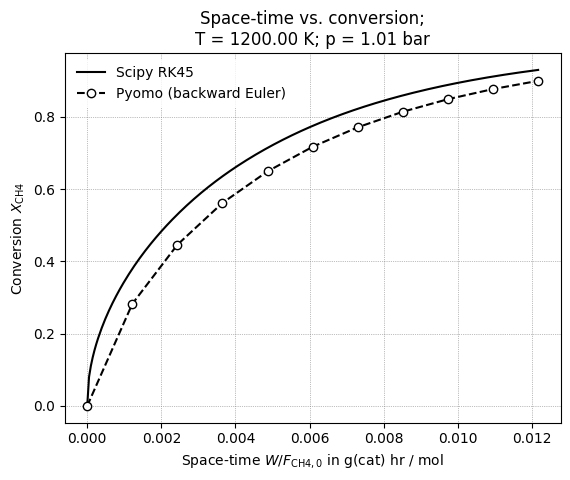

In [35]:
_ = plot_optimization_result_space_time_reforming(block=instance.reformer)

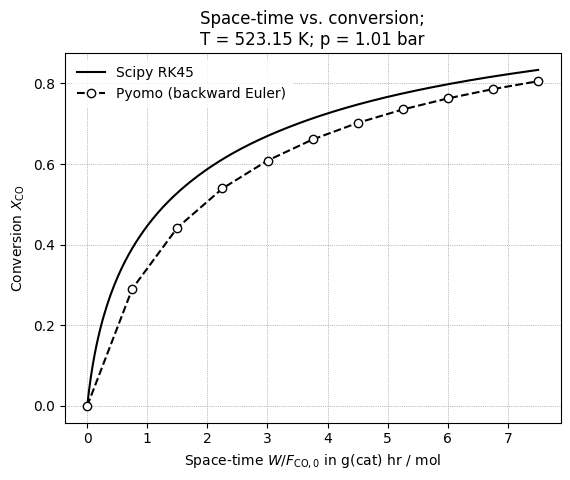

In [36]:
_ = plot_optimization_result_space_time_shift(block=instance.shift)

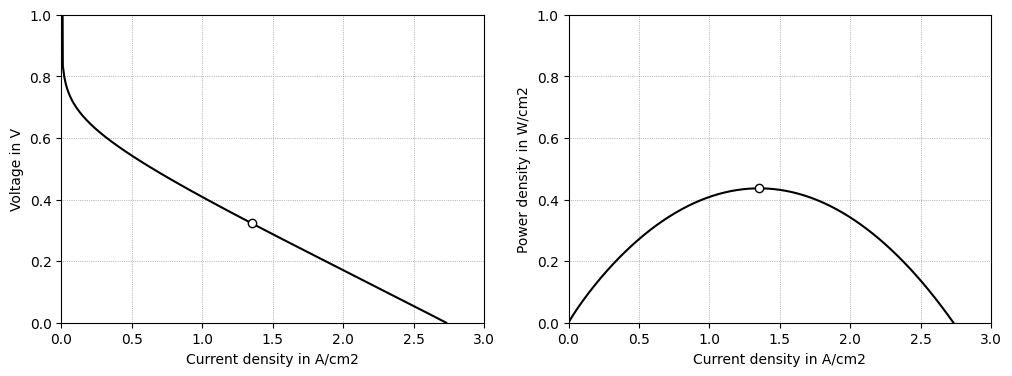

In [37]:
_ = plot_optimization_result_fuel_cell(instance.fuel_cell)

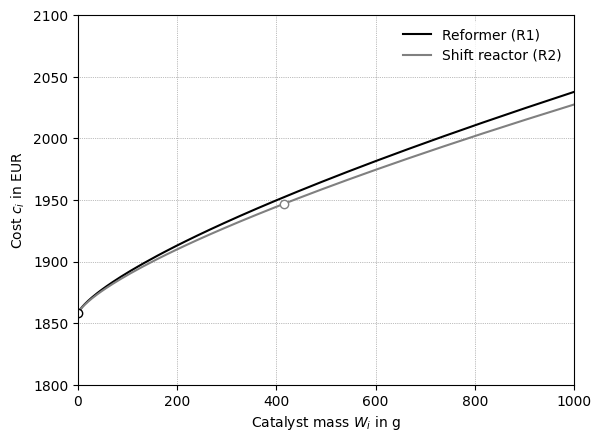

In [38]:
_ = plot_optimization_result_reactor_costs(
    instance,
    fname_cost_coefs=(
        DataID(DataType.SUPPORT, Chapter.METHODS, 6).get_path(fail_exists=False)
        / f"{FILE_DATE_REGRESSION}_cost_coefficients.json"
    ),
)

### Parameter sweep
[back](#Table-of-contents)

In [39]:
from itertools import product
import yaml

In [40]:
from phdtools.optimization import FUEL_CELL_POWER_SI_LB, FUEL_CELL_POWER_SI_UB

In [41]:
# thermalEfficiencyRange = np.array([0.8])
step = 50
electricalPowerRange = np.arange(
    FUEL_CELL_POWER_SI_LB, FUEL_CELL_POWER_SI_UB + step, step
)
electricalPowerRange

if not os.path.exists(OUTDIR):
    os.makedirs(OUTDIR)

    run_id = 1
    for electricalPowerSI in electricalPowerRange:

        create_case(
            run_id=run_id,
            # epsThermalEfficiency=thermalEfficiency,
            epsElectricalPowerSI=electricalPowerSI,
            fname_cost_coefs=(
                DataID(DataType.SUPPORT, Chapter.METHODS, 6).get_path(fail_exists=False)
                / f"{FILE_DATE_COST_COEFS}_cost_coefficients.json"
            ),
            outdir=OUTDIR,
        )

        config = {
            "model": {
                "filename": f"{PROJECT_ROOT}/phdtools/optimization/pyomo/cost_minimization.py"
            },
            "data": {"files": [f"cost_minimization_{run_id}.dat"]},
            "runtime": {
                "logging": "quiet",
                "logfile": f"cost_minimization_{run_id}.log",
                "stream output": True,
            },
            "solvers": [
                {
                    "solver name": "scip",
                    "options": {"limits/time": TIME_LIMIT_SECONDS},
                }
            ],
            "postsolve": {"save results": f"results_{run_id}.yaml"},
        }

        with open(OUTDIR / f"cost_minimization_{run_id}.yaml", "w") as f:
            yaml.dump(config, f, sort_keys=False)

        run_id += 1

In [42]:
if (os.path.exists(OUTDIR)) and (not list(OUTDIR.glob("results*"))):
    !TMPDIR={OUTDIR} && source ./solve_cases.sh

In [43]:
!ls {OUTDIR}

base.dat                  cost_minimization_2.dat   cost_minimization_9.log
cost_minimization_1.dat   cost_minimization_2.log   cost_minimization_9.yaml
cost_minimization_1.log   cost_minimization_2.yaml  fuel_cell.dat
cost_minimization_1.yaml  cost_minimization_3.dat   reformer.dat
cost_minimization_10.dat  cost_minimization_3.log   results_1.yaml
cost_minimization_10.log  cost_minimization_3.yaml  results_10.yaml
cost_minimization_10.yaml cost_minimization_4.dat   results_11.yaml
cost_minimization_11.dat  cost_minimization_4.log   results_12.yaml
cost_minimization_11.log  cost_minimization_4.yaml  results_13.yaml
cost_minimization_11.yaml cost_minimization_5.dat   results_14.yaml
cost_minimization_12.dat  cost_minimization_5.log   results_15.yaml
cost_minimization_12.log  cost_minimization_5.yaml  results_2.yaml
cost_minimization_12.yaml cost_minimization_6.dat   results_3.yaml
cost_minimization_13.dat  cost_minimization_6.log   results_4.yaml
cost_minimization_13.log  cost_minimizat

In [44]:
data_id = DataID(DataType.SUPPORT, Chapter.RESULTS, 1)


@auto_create_path
def save_cost_minimization_results(path, source_dir):

    files = os.listdir(source_dir)

    for fname in files:
        if Path(os.path.join(source_dir, fname)).is_file():
            shutil.copy2(os.path.join(source_dir, fname), path)

    return TODAY


filedate = save_cost_minimization_results(
    data_id,
    source_dir=OUTDIR,
    doc=(
        r"Cost minimization results for different values of "
        r"minimum electrical power ($\varepsilon$-constraints)"
    ),
    overwrite=False,
)

if filedate is not None:
    FILE_DATE = filedate

/Users/marvinmeck/test/phd-tools/phdtools/rdm.py:142: UserWarning: Results path '/Users/marvinmeck/Documents/git/phd-results/SvIvsM' already exists. The data_id has been used before. This may be because the results already exist. Skipping!
  warnings.warn(


In [45]:
!ls {DataID(DataType.SUPPORT, Chapter.RESULTS, 1).get_path(fail_exists=False)}

base.dat                  cost_minimization_2.dat   cost_minimization_9.log
cost_minimization_1.dat   cost_minimization_2.log   cost_minimization_9.yaml
cost_minimization_1.log   cost_minimization_2.yaml  fuel_cell.dat
cost_minimization_1.yaml  cost_minimization_3.dat   reformer.dat
cost_minimization_10.dat  cost_minimization_3.log   results_1.yaml
cost_minimization_10.log  cost_minimization_3.yaml  results_10.yaml
cost_minimization_10.yaml cost_minimization_4.dat   results_11.yaml
cost_minimization_11.dat  cost_minimization_4.log   results_12.yaml
cost_minimization_11.log  cost_minimization_4.yaml  results_13.yaml
cost_minimization_11.yaml cost_minimization_5.dat   results_14.yaml
cost_minimization_12.dat  cost_minimization_5.log   results_15.yaml
cost_minimization_12.log  cost_minimization_5.yaml  results_2.yaml
cost_minimization_12.yaml cost_minimization_6.dat   results_3.yaml
cost_minimization_13.dat  cost_minimization_6.log   results_4.yaml
cost_minimization_13.log  cost_minimizat

#### Solution summary
[back](#Table-of-contents)

In [46]:
from phdtools.optimization.postprocessing import get_fuelCellEfficiency

In [47]:
data_id = DataID(DataType.TABLE, Chapter.RESULTS, 1)

In [48]:
@auto_create_path
def create_cost_minimization_solution_summary(path, results_id):
    model = create_abstract_model()

    pathlist = list(results_id.get_path(fail_exists=False).glob("results*"))

    run_ids = np.zeros(len(pathlist), dtype=int)

    variableCostsValues = np.full(len(pathlist), np.nan)

    thermalPowerValuesSI = np.full(len(pathlist), np.nan)
    electricalPowerValuesSI = np.full(len(pathlist), np.nan)

    thermalEfficiencyValues = np.full(len(pathlist), np.nan)
    electricalEfficiencyValues = np.full(len(pathlist), np.nan)

    cellVoltageValues = np.full(len(pathlist), np.nan)
    currentDensityValues = np.full(len(pathlist), np.nan)
    powerDensityValues = np.full(len(pathlist), np.nan)

    molarFlowRateMethaneInValues = np.full(len(pathlist), np.nan)
    steamToCarbonRatioValues = np.full(len(pathlist), np.nan)
    airToFuelRatioValues = np.full(len(pathlist), np.nan)

    totalWaterIn = np.full(len(pathlist), np.nan)
    totalWaterOut = np.full(len(pathlist), np.nan)
    totalWaterProduced = np.full(len(pathlist), np.nan)

    liquidWaterIn = np.full(len(pathlist), np.nan)
    liquidWaterOut = np.full(len(pathlist), np.nan)
    waterVapourOut = np.full(len(pathlist), np.nan)

    fuelCellActiveAreaValues = np.full(len(pathlist), np.nan)
    catalystMassReformerValues = np.full(len(pathlist), np.nan)
    catalystMassShiftValues = np.full(len(pathlist), np.nan)

    normalizedTotalContributionValues = np.full(len(pathlist), np.nan)
    marketShareValues = np.full(len(pathlist), np.nan)

    priceValues = np.full(len(pathlist), np.nan)
    variableCostsValues = np.full(len(pathlist), np.nan)

    thermalEfficiencyValues = np.full(len(pathlist), np.nan)
    electricalEfficiencyValues = np.full(len(pathlist), np.nan)

    thermalPowerValuesSI = np.full(len(pathlist), np.nan)
    electricalPowerValuesSI = np.full(len(pathlist), np.nan)

    cellVoltageValues = np.full(len(pathlist), np.nan)
    currentDensityValues = np.full(len(pathlist), np.nan)
    powerDensityValues = np.full(len(pathlist), np.nan)

    molarFlowRateMethaneInValues = np.full(len(pathlist), np.nan)
    steamToCarbonRatioValues = np.full(len(pathlist), np.nan)
    methaneConversionValues = np.full(len(pathlist), np.nan)
    reformerTemperatureValues = np.full(len(pathlist), np.nan)
    selectivityValues = np.full(len(pathlist), np.nan)
    molarFlowRateHydrogenReformerOut = np.full(len(pathlist), np.nan)

    shiftTemperatureValues = np.full(len(pathlist), np.nan)
    moleFractionHydrogenShiftInValues = np.full(len(pathlist), np.nan)
    moleFractionHydrogenShiftOutValues = np.full(len(pathlist), np.nan)

    moleFractionCarbonMonoxideShiftInValues = np.full(len(pathlist), np.nan)
    moleFractionCarbonMonoxideShiftOutValues = np.full(len(pathlist), np.nan)

    molarFlowRateCarbonMonoxideShiftIn = np.full(len(pathlist), np.nan)
    carbonMonoxideConversionValues = np.full(len(pathlist), np.nan)

    hydrogenConsumptionValues = np.full(len(pathlist), np.nan)
    hydrogenProductionValues = np.full(len(pathlist), np.nan)

    airToFuelRatioValues = np.full(len(pathlist), np.nan)
    oxygenToFuelRationValues = np.full(len(pathlist), np.nan)

    totalWaterIn = np.full(len(pathlist), np.nan)
    totalWaterOut = np.full(len(pathlist), np.nan)
    totalWaterProduced = np.full(len(pathlist), np.nan)

    liquidWaterIn = np.full(len(pathlist), np.nan)
    liquidWaterOut = np.full(len(pathlist), np.nan)
    waterVapourOut = np.full(len(pathlist), np.nan)

    fuelCellActiveAreaValues = np.full(len(pathlist), np.nan)
    catalystMassReformerValues = np.full(len(pathlist), np.nan)
    catalystMassShiftValues = np.full(len(pathlist), np.nan)

    for num, pth in enumerate(pathlist):
        if pth.is_file():
            run_id = pth.stem.split("_")[-1]
            with chdir(results_id.get_path(fail_exists=False)):
                dp = pyo.DataPortal(filename=f"cost_minimization_{run_id}.dat")

            instance = pyomo_load_solution(pth, model=model, modeldata=dp)

            run_ids[num] = int(run_id)

            # Economics
            # marketShareValues[num] = pyo.value(instance.sampleAverageChoiceProbability)
            # priceValues[num] = pyo.value(instance.priceEuro)
            variableCostsValues[num] = pyo.value(instance.variableCostsEuro)

            # Power class of the system
            thermalPowerValuesSI[num] = pyo.value(instance.NOMINAL_THERMAL_POWER_SI)
            electricalPowerValuesSI[num] = pyo.value(instance.electricalPowerSI)

            # Efficiency
            thermalEfficiencyValues[num] = pyo.value(instance.thermalEfficiency)
            electricalEfficiencyValues[num] = pyo.value(instance.electricalEfficiency)

            # Fuel cell operation
            cellVoltageValues[num] = pyo.value(instance.fuel_cell.cellPotentialSI)
            currentDensityValues[num] = pyo.value(instance.fuel_cell.currentDensitySI)
            powerDensityValues[num] = pyo.value(instance.fuel_cell.powerDensitySI)

            # Hydrogen reactionn
            hydrogenProductionValues[num] = pyo.value(
                instance.shift.molarFlowRateSI[
                    "H2(ref)", instance.shift.setTimeSteps.last()
                ]
                - instance.reformer.molarFlowRateSI[
                    "H2(ref)", instance.reformer.setTimeSteps.first()
                ]
            )
            hydrogenConsumptionValues[num] = pyo.value(
                instance.fuel_cell.totalChargeTransferRateSI
                / (2 * instance.fuel_cell.FARADAY_CONST_SI)
            )

            # Fuel processing
            reformerTemperatureValues[num] = pyo.value(
                instance.reformer.temperatureKelvin
            )

            molarFlowRateMethaneInValues[num] = pyo.value(
                instance.molarFlowRateInSI["C1H4(g)"]
            )
            steamToCarbonRatioValues[num] = pyo.value(
                instance.molarFlowRateInSI["H2O1(l)"]
                / instance.molarFlowRateInSI["C1H4(g)"]
            )
            methaneConversionValues[num] = pyo.value(
                1
                - instance.reformer.molarFlowRateSI[
                    "C1H4(g)", instance.reformer.setTimeSteps.last()
                ]
                / instance.reformer.molarFlowRateSI[
                    "C1H4(g)", instance.reformer.setTimeSteps.first()
                ]
            )
            selectivityValues[num] = pyo.value(
                instance.reformer.molarFlowRateSI[
                    "H2(ref)", instance.reformer.setTimeSteps.last()
                ]
                / instance.reformer.molarFlowRateSI[
                    "C1O1(g)", instance.reformer.setTimeSteps.last()
                ]
            )

            molarFlowRateCarbonMonoxideShiftIn[num] = pyo.value(
                instance.shift.molarFlowRateSI[
                    "C1O1(g)", instance.shift.setTimeSteps.first()
                ]
            )

            shiftTemperatureValues[num] = pyo.value(instance.shift.temperatureKelvin)

            moleFractionHydrogenShiftInValues[num] = pyo.value(
                instance.shift.molarFlowRateSI[
                    "H2(ref)", instance.shift.setTimeSteps.first()
                ]
                / sum(
                    instance.shift.molarFlowRateSI[
                        :, instance.shift.setTimeSteps.first()
                    ]
                )
            )
            moleFractionHydrogenShiftOutValues[num] = pyo.value(
                instance.shift.molarFlowRateSI[
                    "H2(ref)", instance.shift.setTimeSteps.last()
                ]
                / sum(
                    instance.shift.molarFlowRateSI[
                        :, instance.shift.setTimeSteps.last()
                    ]
                )
            )

            moleFractionCarbonMonoxideShiftInValues[num] = pyo.value(
                instance.shift.molarFlowRateSI[
                    "C1O1(g)", instance.shift.setTimeSteps.first()
                ]
                / sum(
                    instance.shift.molarFlowRateSI[
                        :, instance.shift.setTimeSteps.first()
                    ]
                )
            )
            moleFractionCarbonMonoxideShiftOutValues[num] = pyo.value(
                instance.shift.molarFlowRateSI[
                    "C1O1(g)", instance.shift.setTimeSteps.last()
                ]
                / sum(
                    instance.shift.molarFlowRateSI[
                        :, instance.shift.setTimeSteps.last()
                    ]
                )
            )

            carbonMonoxideConversionValues[num] = pyo.value(
                1
                - instance.shift.molarFlowRateSI[
                    "C1O1(g)", instance.shift.setTimeSteps.last()
                ]
                / instance.shift.molarFlowRateSI[
                    "C1O1(g)", instance.shift.setTimeSteps.first()
                ]
            )

            # Air supply
            oxygenToFuelRationValues[num] = pyo.value(
                instance.molarFlowRateInSI["O2(ref)"]
                / instance.molarFlowRateInSI["C1H4(g)"]
            )
            airToFuelRatioValues[num] = pyo.value(
                sum(instance.molarFlowRateInSI[j] for j in instance.setCompoundsAir)
                / instance.molarFlowRateInSI["C1H4(g)"]
            )

            # Water balance
            totalWaterIn[num] = pyo.value(
                instance.molarFlowRateInSI["H2O1(g)"]
                + instance.molarFlowRateInSI["H2O1(l)"]
            )
            totalWaterOut[num] = pyo.value(
                instance.molarFlowRateOutSI["H2O1(g)"]
                + instance.molarFlowRateOutSI["H2O1(l)"]
            )
            totalWaterProduced[num] = pyo.value(instance.molarFlowRateProductWaterOutSI)

            liquidWaterIn[num] = pyo.value(instance.molarFlowRateInSI["H2O1(l)"])
            liquidWaterOut[num] = pyo.value(instance.molarFlowRateOutSI["H2O1(l)"])
            waterVapourOut[num] = pyo.value(instance.molarFlowRateOutSI["H2O1(g)"])

            # Primary design variables
            fuelCellActiveAreaValues[num] = pyo.value(
                instance.fuel_cell.totalActiveAreaSI
            )
            catalystMassReformerValues[num] = pyo.value(
                instance.reformer.massCatalystSI
            )
            catalystMassShiftValues[num] = pyo.value(instance.shift.massCatalystSI)

    df = (
        pd.DataFrame(
            {
                "RUN_ID": run_ids,
                # Economics
                # "Normalized total contribution (Euro)": marketShareValues*(priceValues - variableCostsValues),
                # "Market share (percent)": 100*marketShareValues,
                # "Price (EUR)": priceValues,
                "Variable costs (Euro)": variableCostsValues,
                # "Contribution margin (EUR)": priceValues - variableCostsValues,
                # "Markup (EUR)": priceValues/variableCostsValues,
                # Power class of the system
                "Thermal power (kW)": thermalPowerValuesSI * 1e-3,
                "Electrical power (kW)": electricalPowerValuesSI * 1e-3,
                # Efficiency
                "Thermal efficiency": thermalEfficiencyValues,
                "Electrical efficiency": electricalEfficiencyValues,
                "Fuel cell efficiency": get_fuelCellEfficiency(cellVoltageValues),
                # Fuel cell operation
                "Fuel cell voltage (V)": cellVoltageValues,
                "Current density (A/m2)": currentDensityValues * 1e-4,
                "Power density (W/m2)": powerDensityValues * 1e-4,
                # Hydrogen reaction
                "Total hydrogen consumption (mol/h)": hydrogenConsumptionValues * 3600,
                "Total hydrogen production (mol/h)": hydrogenProductionValues * 3600,
                # Fuel processing
                "Methane feed (mol/h)": molarFlowRateMethaneInValues * 3600,
                "Steam-to-carbon ratio (H2O/CH4)": steamToCarbonRatioValues,
                "Reformer temperature (K)": reformerTemperatureValues,
                "Space-time reformer (g(cat)*h/mol)": 1
                / 3.6
                * catalystMassReformerValues
                / molarFlowRateMethaneInValues,
                "Methane conversion": methaneConversionValues,
                "Selectivity reforming (H2/CO)": selectivityValues,
                "Mole fraction CO shift in": moleFractionCarbonMonoxideShiftInValues,
                "Mole fraction H2 shift in": moleFractionHydrogenShiftInValues,
                "Shift temperature (K)": shiftTemperatureValues,
                "Space-time shift (g(cat)*h/mol)": 1
                / 3.6
                * catalystMassShiftValues
                / molarFlowRateCarbonMonoxideShiftIn,
                "Carbon monoxide conversion": carbonMonoxideConversionValues,
                "Mole fraction CO shift out": moleFractionCarbonMonoxideShiftOutValues,
                "Mole fraction H2 shift out": moleFractionHydrogenShiftOutValues,
                # Air supply
                "Oxygen-to-fuel ratio (O2/CH4)": oxygenToFuelRationValues,
                "Air-to-fuel ratio (Air/CH4)": airToFuelRatioValues,
                # Water balance
                "Total water in (mol/h)": totalWaterIn * 3600,
                "Total water out (mol/h)": totalWaterOut * 3600,
                "Total water produced (mol/h)": totalWaterProduced * 3600,
                "Liquid water in (mol/h)": liquidWaterIn * 3600,
                "Liquid water out (mol/h)": liquidWaterOut * 3600,
                "Water vapour out (mol/h)": waterVapourOut * 3600,
                # Primary design variables
                "Fuel cell area (cm2)": fuelCellActiveAreaValues * 1e4,
                "Catalyst mass reformer (g)": catalystMassReformerValues * 1e3,
                "Catalyst mass shift reactor (g)": catalystMassShiftValues * 1e3,
            },
        )
        .set_index("RUN_ID")
        .sort_index()
    )

    description = (
        "Solution summary for the cost minimization problem evaluated for different \n"
        "values of min. electrical power (e-constraint).\n"
        f"For parameter values and solver configurations see: {results_id.to_sqid()}"
    )

    fname = path / f"{TODAY}_cost_minimization_solution_summary.csv"
    with open(fname, "w") as f:
        write_metadata(f, description)
        df.T.to_csv(f, index_label="RUN_ID")


create_cost_minimization_solution_summary(
    data_id,
    results_id=DataID(DataType.SUPPORT, Chapter.RESULTS, 1),
    doc=(
        r"Solution summary for the cost minimization problem evaluated for different values "
        r"of minimum thermal efficiency and electrical power ($\varepsilon$-constraints). "
    ),
    overwrite=overwrite,
)

/Users/marvinmeck/test/phd-tools/phdtools/rdm.py:142: UserWarning: Results path '/Users/marvinmeck/Documents/git/phd-results/tSyuJc' already exists. The data_id has been used before. This may be because the results already exist. Skipping!
  warnings.warn(


In [49]:
!ls {DataID(DataType.TABLE, Chapter.RESULTS, 1).get_path(fail_exists=False)}

260419_cost_minimization_solution_summary.csv


In [50]:
df = pd.read_csv(
    DataID(DataType.TABLE, Chapter.RESULTS, 1).get_path(fail_exists=False)
    / f"{FILE_DATE}_cost_minimization_solution_summary.csv",
    index_col=0,
    comment="#",
)
df

,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
RUN_ID,,,,,,,,,,,,,,,
Variable costs (Euro),8939.509708,8962.677953,8985.845940,9009.013668,9032.181142,9055.348360,9078.515324,9101.682035,9124.848495,9148.014706,9171.180668,9194.346382,9217.511849,9240.677071,9263.842053
Thermal power (kW),12.500000,12.500000,12.500000,12.500000,12.500000,12.500000,12.500000,12.500000,12.500000,12.500000,12.500000,12.500000,12.500000,12.500000,12.500000
Electrical power (kW),0.300000,0.350000,0.400000,0.450000,0.500000,0.550000,0.600000,0.650000,0.700000,0.750000,0.800000,0.850000,0.900000,0.950000,1.000000
Thermal efficiency,0.864860,0.861495,0.858156,0.854842,0.851555,0.848292,0.845054,0.841841,0.838652,0.835488,0.832347,0.829229,0.826135,0.823064,0.820016
Electrical efficiency,0.020757,0.024122,0.027461,0.030774,0.034062,0.037325,0.040563,0.043776,0.046965,0.050129,0.053270,0.056388,0.059482,0.062553,0.065601
Fuel cell efficiency,0.217639,0.217639,0.217639,0.217641,0.217639,0.217639,0.217639,0.217639,0.217638,0.217639,0.217639,0.217639,0.217639,0.217639,0.217639
Fuel cell voltage (V),0.322727,0.322727,0.322727,0.322731,0.322727,0.322727,0.322727,0.322727,0.322727,0.322727,0.322727,0.322727,0.322727,0.322727,0.322727
Current density (A/m2),1.351910,1.351910,1.351910,1.351896,1.351910,1.351910,1.351910,1.351909,1.351912,1.351910,1.351910,1.351910,1.351910,1.351910,1.351910
Power density (W/m2),0.436298,0.436298,0.436298,0.436298,0.436298,0.436298,0.436298,0.436298,0.436298,0.436298,0.436298,0.436298,0.436298,0.436298,0.436298


#### Pareto surface
[back](#Table-of-contents)

In [51]:
import pandas as pd
from phdtools.optimization.postprocessing import pyomo_load_solution

In [52]:
data_id = DataID(DataType.FIGURE, Chapter.RESULTS, 1)


@auto_create_path
def save_cost_minimization_results_plot(path, results_id):
    model = create_abstract_model()

    pathlist = list(results_id.get_path(fail_exists=False).glob("results*"))

    run_ids = np.zeros(len(pathlist), dtype=int)
    variableCostsValues = np.full(len(pathlist), np.nan)
    thermalEfficiencyValues = np.full(len(pathlist), np.nan)
    electricalPowerValuesSI = np.full(len(pathlist), np.nan)

    for num, pth in enumerate(pathlist):
        if pth.is_file():
            run_id = pth.stem.split("_")[-1]
            with chdir(results_id.get_path(fail_exists=False)):
                dp = pyo.DataPortal(filename=f"cost_minimization_{run_id}.dat")

            instance = pyomo_load_solution(pth, model=model, modeldata=dp)

            run_ids[num] = int(run_id)
            thermalEfficiencyValues[num] = pyo.value(instance.thermalEfficiency)
            electricalPowerValuesSI[num] = pyo.value(instance.electricalPowerSI)
            variableCostsValues[num] = pyo.value(instance.variableCostsEuro)

    df = (
        pd.DataFrame(
            {
                "RUN_ID": run_ids,
                "Thermal efficiency": thermalEfficiencyValues,
                "Electrical power (kW)": electricalPowerValuesSI * 1e-3,
                "Variable costs (Euro)": variableCostsValues,
            },
        )
        .set_index("RUN_ID")
        .sort_index()
    )

    # frame = df.copy()
    # frame["electricalPowerSI"] = np.round(df["electricalPowerSI"] * 1e4) / 1e4
    # frame["thermalEfficiency"] = np.round(df["thermalEfficiency"] * 1e4) / 1e4
    # frame["variableCosts"] = np.round(df["variableCosts"] * 1e2) / 1e2

    # frame = frame.drop_duplicates()

    description = (
        r"Optimal values for the variable production costs, thermal efficiency,\n"
        r"and electrical power based on the cost minimisation problem.\n"
        # "The results were rounded to four decimal places and filtered to only\n"
        # "include unique pairs of thermal efficiency and electrical power.\n"
        f"For parameter values and solver configurations see: {results_id.to_sqid()}."
    )

    fname = path / f"{TODAY}_cost_minimization_results_plot.csv"
    with open(fname, "w") as f:
        write_metadata(f, description)
        df.to_csv(f)


save_cost_minimization_results_plot(
    data_id,
    results_id=DataID(DataType.SUPPORT, Chapter.RESULTS, 1),
    doc=(
        r"Optimal values for the variable production costs, thermal efficiency, "
        r"and electrical power based on the cost minimisation problem. "
    ),
    overwrite=overwrite,
)

/Users/marvinmeck/test/phd-tools/phdtools/rdm.py:142: UserWarning: Results path '/Users/marvinmeck/Documents/git/phd-results/nWqpfL' already exists. The data_id has been used before. This may be because the results already exist. Skipping!
  warnings.warn(


In [53]:
!ls {DataID(DataType.FIGURE, Chapter.RESULTS, 1).get_path(fail_exists=False)}

260419_cost_minimization_results_plot.csv


In [54]:
df = pd.read_csv(
    DataID(DataType.FIGURE, Chapter.RESULTS, 1).get_path(fail_exists=False)
    / f"{FILE_DATE}_cost_minimization_results_plot.csv",
    index_col=0,
    comment="#",
)
df

,Thermal efficiency,Electrical power (kW),Variable costs (Euro)
RUN_ID,,,
1,0.864860,0.30,8939.509708
2,0.861495,0.35,8962.677953
3,0.858156,0.40,8985.845940
4,0.854842,0.45,9009.013668
5,0.851555,0.50,9032.181142
6,0.848292,0.55,9055.348360
7,0.845054,0.60,9078.515324
8,0.841841,0.65,9101.682035
9,0.838652,0.70,9124.848495


(np.float64(0.8036354763511786), np.float64(0.8709445606807332))

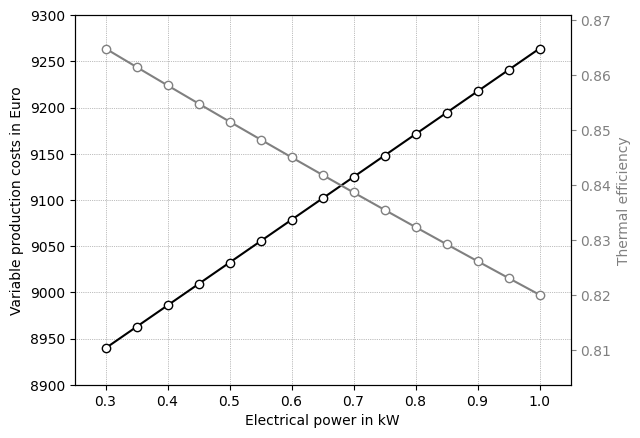

In [55]:
from phdtools.plots.optimization.postprocessing import create_power_cost_efficiency_plot

fig = create_power_cost_efficiency_plot(
    fname=(
        DataID(DataType.FIGURE, Chapter.RESULTS, 1).get_path(fail_exists=False)
        / f"{FILE_DATE}_cost_minimization_results_plot.csv"
    )
)
ax = fig.gca()
ax.get_ylim()

In [56]:
from phdtools.optimization import THERMAL_EFFICIENCY_STATUS_QUO

THERMAL_EFFICIENCY_STATUS_QUO

np.float64(0.8102838820461392)

#### Process variables and operating parameters
[back](#Table-of-contents)

In [57]:
from phdtools.optimization.postprocessing import (
    get_optimization_results_space_time_reforming,
    get_optimization_results_space_time_shift,
)

In [58]:
# !ls {DataID(DataType.SUPPORT, Chapter.RESULTS, 1).get_path(fail_exists=False)}

In [59]:
model = create_abstract_model()

run_id = 8

fname = (
    DataID(DataType.SUPPORT, Chapter.RESULTS, 1).get_path(fail_exists=False)
    / f"results_{run_id}.yaml"
)
with chdir(DataID(DataType.SUPPORT, Chapter.RESULTS, 1).get_path(fail_exists=False)):
    dp = pyo.DataPortal(filename=f"cost_minimization_{run_id}.dat")

instance = pyomo_load_solution(fname, model=model, modeldata=dp)

WARNING (W1002): Setting Var 'reformer.adsorptionCoefScaled['H2(ref)']' to a
numeric value `0.01569507649807912` outside the bounds (0.01569508619070076,
1.0).
    See also https://pyomo.readthedocs.io/en/stable/errors.html#w1002
WARNING (W1002): Setting Var 'shift.temperatureScaled' to a numeric value
`1.0000000044915731` outside the bounds (0.8661951639109242, 1.0).
    See also https://pyomo.readthedocs.io/en/stable/errors.html#w1002
WARNING (W1002): Setting Var 'shift.rateConstantScaled' to a numeric value
`1.0000000039063792` outside the bounds (0.8742855501588747, 1.0).
    See also https://pyomo.readthedocs.io/en/stable/errors.html#w1002
WARNING (W1002): Setting Var 'shift.equilibriumConstScaled' to a numeric value
`0.24298431293644196` outside the bounds (0.24298432293190536, 1.0).
    See also https://pyomo.readthedocs.io/en/stable/errors.html#w1002
WARNING (W1002): Setting Var 'shift.adsorptionCoefScaled['C1O2(g)']' to a
numeric value `0.7062002250845664` outside the bounds (

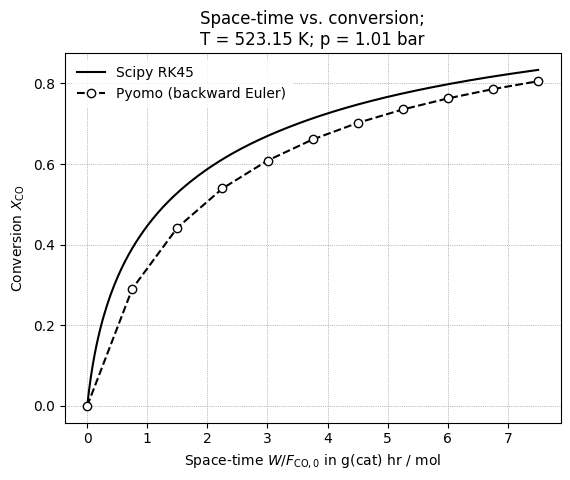

In [60]:
_ = plot_optimization_result_space_time_shift(instance.shift)

In [61]:
data_id = DataID(DataType.FIGURE, Chapter.RESULTS, 2)


@auto_create_path
def save_space_time_conversion_validation(path, results_id):

    pathlist = list(results_id.get_path(fail_exists=False).glob("results*"))

    run_ids = np.zeros(len(pathlist), dtype=int)

    for num, pth in enumerate(pathlist):
        if pth.is_file():
            run_id = pth.stem.split("_")[-1]
            with chdir(results_id.get_path(fail_exists=False)):
                dp = pyo.DataPortal(filename=f"cost_minimization_{run_id}.dat")

            instance = pyomo_load_solution(pth, model=model, modeldata=dp)

            data_pyomo, data_scipy = get_optimization_results_space_time_reforming(
                instance.reformer
            )

            data_pyomo["spaceTimeSI"] = data_pyomo["spaceTimeSI"] / 3.6
            data_pyomo = data_pyomo.rename(
                columns={
                    "spaceTimeSI": "W/F_CH4,0 (g(cat) h/mol)",
                    "conversion": "XCH4",
                }
            )

            data_scipy["spaceTimeSI"] = data_scipy["spaceTimeSI"] / 3.6
            data_scipy = data_scipy.rename(
                columns={
                    "spaceTimeSI": "W/F_CH4,0 (g(cat) h/mol)",
                    "conversion": "XCH4",
                }
            )

            description = (
                f"Isothermal plug flow reactor simulation data; see Xu and Froment (1989).\n"
                f"Optimization results from the cost-minimization problem implementing a backward Euler discetization.\n"
                f"For parameter values and solver configurations see: {results_id.to_sqid()}"
                f"\n\n"
                f"References:\n"
                f"-----------\n"
                f'Xu, J. and Froment, G.F. (1989) "Methane steam reforming, methanation \n'
                f'    and water-gas shift: I. Intrinsic kinetics," AIChE Journal, 35(1), \n'
                f"    pp. 88–96. Available at: https://doi.org/10.1002/aic.690350109.\n"
                f'Virtanen, P. et al. (2020) "SciPy 1.0: fundamental algorithms for scientific \n'
                f'    computing in Python," Nature Methods, 17(3), pp. 261–272. \n'
                f"    Available at: https://doi.org/10.1038/s41592-019-0686-2.\n"
            )
            fname = (
                path
                / f"{TODAY}_reformer_space_time_conversion_cost_minimization_{run_id}.csv"
            )
            with open(fname, "w") as f:
                write_metadata(f, description)
                data_pyomo.to_csv(f, index=False)

            description = (
                (
                    f"Isothermal plug flow reactor simulation data; see Xu and Froment (1989).\n"
                    f"Reference solution for space-time and conversion solved using the RKF45 implementation\n"
                    f"of scipy.integrate.solve_ivp (scipy {scipy.__version__}). \n"
                    f"Equilibrium constant modelled by a van't Hoff model based on Allison (2013), see {DataID(DataType.FIGURE, Chapter.UNUSED, 11).to_sqid()}.\n\n"
                    f"Parameters: \n"
                    f"  T = {pyo.value(instance.reformer.temperatureKelvin)} K;\n"
                    f"  p = {pyo.value(instance.reformer.pressureBar)} bar;\n"
                )
                + "; \n".join(
                    f"  x_{k},0 = {pyo.value(instance.reformer.molarFlowRateSI[k,instance.reformer.setTimeSteps.first()]/sum(instance.reformer.molarFlowRateSI[:,instance.reformer.setTimeSteps.first()]))}"
                    for k in instance.reformer.setReactingCompounds
                )
                + (
                    f"\n\n"
                    f"References:\n"
                    f"-----------\n"
                    f'Xu, J. and Froment, G.F. (1989) "Methane steam reforming, methanation \n'
                    f'    and water-gas shift: I. Intrinsic kinetics," AIChE Journal, 35(1), \n'
                    f"    pp. 88–96. Available at: https://doi.org/10.1002/aic.690350109.\n"
                    f'Virtanen, P. et al. (2020) "SciPy 1.0: fundamental algorithms for scientific \n'
                    f'    computing in Python," Nature Methods, 17(3), pp. 261–272. \n'
                    f"    Available at: https://doi.org/10.1038/s41592-019-0686-2.\n"
                )
            )
            fname = path / f"{TODAY}_reformer_space_time_conversion_rk45_{run_id}.csv"
            with open(fname, "w") as f:
                write_metadata(f, description)
                data_scipy.to_csv(f, index=False)

            data_pyomo, data_scipy = get_optimization_results_space_time_shift(
                instance.shift
            )

            data_pyomo["spaceTimeSI"] = data_pyomo["spaceTimeSI"] / 3.6
            data_pyomo = data_pyomo.rename(
                columns={"spaceTimeSI": "W/F_CO,0 (g(cat) h/mol)", "conversion": "XCO"}
            )

            data_scipy["spaceTimeSI"] = data_scipy["spaceTimeSI"] / 3.6
            data_scipy = data_scipy.rename(
                columns={"spaceTimeSI": "W/F_CO,0 (g(cat) h/mol)", "conversion": "XCO"}
            )

            description = (
                f"Isothermal plug flow reactor simulation data (LH1 model); see Mendes et al. (2010)\n"
                f"Optimization results from the cost-minimization problem implementing a backward Euler discetization.\n"
                f"For parameter values and solver configurations see: {results_id.to_sqid()}"
                f"\n\n"
                f"References:\n"
                f"-----------\n"
                f"Mendes, D. et al. (2010) “Determination of the Low-Temperature Water−Gas Shift Reaction \n"
                f"   Kinetics Using a Cu-Based Catalyst,” Industrial & Engineering Chemistry Research, 49(22), pp. 11269–11279.\n"
                f"   Available at: https://doi.org/10.1021/ie101137b.\n\n"
            )
            fname = (
                path
                / f"{TODAY}_shift_space_time_conversion_cost_minimization_{run_id}.csv"
            )
            with open(fname, "w") as f:
                write_metadata(f, description)
                data_pyomo.to_csv(f, index=False)

            description = (
                (
                    f"Isothermal plug flow reactor simulation data (LH1 model); see Mendes et al. (2010)\n"
                    f"Reference solution for space-time and conversion solved using the RKF45 implementation\n"
                    f"of scipy.integrate.solve_ivp (scipy {scipy.__version__}). \n"
                    f"Equilibrium constant modelled by a van't Hoff model based on Allison (2013), see {DataID(DataType.FIGURE, Chapter.UNUSED, 11).to_sqid()}.\n\n"
                    f"Parameters: \n"
                    f"  T = {pyo.value(instance.shift.temperatureKelvin)} K;\n"
                    f"  p = {pyo.value(instance.shift.pressureBar)} bar;\n"
                )
                + "; \n".join(
                    f"  x_{k},0 = {pyo.value(instance.shift.molarFlowRateSI[k,instance.shift.setTimeSteps.first()]/sum(instance.shift.molarFlowRateSI[:,instance.shift.setTimeSteps.first()]))}"
                    for k in instance.shift.setReactingCompounds
                )
                + (
                    "\n\n"
                    "References:\n"
                    "-----------\n"
                    'Allison, T. (2013) "NIST-JANAF Thermochemical Tables - SRD 13." National Institute.\n'
                    "    of Standards and Technology. Available at: https://doi.org/10.18434/T42S31.\n\n"
                    "Mendes, D. et al. (2010) “Determination of the Low-Temperature Water−Gas Shift Reaction \n"
                    "   Kinetics Using a Cu-Based Catalyst,” Industrial & Engineering Chemistry Research, 49(22), pp. 11269–11279.\n"
                    "   Available at: https://doi.org/10.1021/ie101137b.\n\n"
                    'Virtanen, P. et al. (2020) "SciPy 1.0: fundamental algorithms for scientific \n'
                    '   computing in Python," Nature Methods, 17(3), pp. 261–272. \n'
                    "   Available at: https://doi.org/10.1038/s41592-019-0686-2.\n"
                )
            )
            fname = path / f"{TODAY}_shift_space_time_conversion_rk45_{run_id}.csv"
            with open(fname, "w") as f:
                write_metadata(f, description)
                data_scipy.to_csv(f, index=False)


save_space_time_conversion_validation(
    data_id,
    results_id=DataID(DataType.SUPPORT, Chapter.RESULTS, 1),
    doc=(
        r"Validation of the space-time vs. conversion values obtained through cost-minimization (backward Euler discretization) "
        r"against reference values from numerical integration of the respective initial value problems using the \scipy{} "
        r"implementation of the Runge-Kutta-Feldmann (RKF45) method."
    ),
    overwrite=overwrite,
)

/Users/marvinmeck/test/phd-tools/phdtools/rdm.py:142: UserWarning: Results path '/Users/marvinmeck/Documents/git/phd-results/tCyuJF' already exists. The data_id has been used before. This may be because the results already exist. Skipping!
  warnings.warn(


In [62]:
!ls {DataID(DataType.FIGURE, Chapter.RESULTS, 2).get_path(fail_exists=False)}

260419_reformer_space_time_conversion_cost_minimization_1.csv
260419_reformer_space_time_conversion_cost_minimization_10.csv
260419_reformer_space_time_conversion_cost_minimization_11.csv
260419_reformer_space_time_conversion_cost_minimization_12.csv
260419_reformer_space_time_conversion_cost_minimization_13.csv
260419_reformer_space_time_conversion_cost_minimization_14.csv
260419_reformer_space_time_conversion_cost_minimization_15.csv
260419_reformer_space_time_conversion_cost_minimization_2.csv
260419_reformer_space_time_conversion_cost_minimization_3.csv
260419_reformer_space_time_conversion_cost_minimization_4.csv
260419_reformer_space_time_conversion_cost_minimization_5.csv
260419_reformer_space_time_conversion_cost_minimization_6.csv
260419_reformer_space_time_conversion_cost_minimization_7.csv
260419_reformer_space_time_conversion_cost_minimization_8.csv
260419_reformer_space_time_conversion_cost_minimization_9.csv
260419_reformer_space_time_conversion_rk45_1.csv
260419_reformer

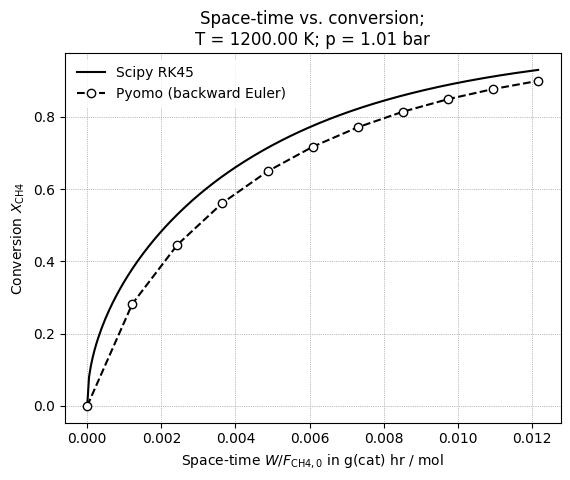

In [63]:
_ = plot_optimization_result_space_time_reforming(instance.reformer)

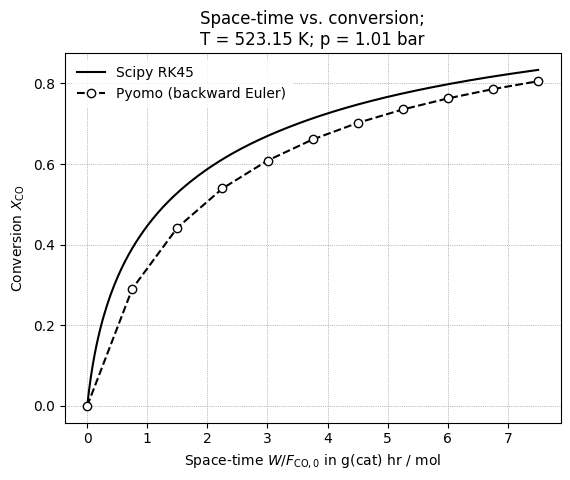

In [64]:
_ = plot_optimization_result_space_time_shift(instance.shift)

In [65]:
model = create_abstract_model()

run_id = 8

fname = (
    DataID(DataType.SUPPORT, Chapter.RESULTS, 1).get_path(fail_exists=False)
    / f"results_{run_id}.yaml"
)
with chdir(DataID(DataType.SUPPORT, Chapter.RESULTS, 1).get_path(fail_exists=False)):
    dp = pyo.DataPortal(filename=f"cost_minimization_{run_id}.dat")

instance = pyomo_load_solution(fname, model=model, modeldata=dp)

WARNING (W1002): Setting Var 'reformer.adsorptionCoefScaled['H2(ref)']' to a
numeric value `0.01569507649807912` outside the bounds (0.01569508619070076,
1.0).
    See also https://pyomo.readthedocs.io/en/stable/errors.html#w1002
WARNING (W1002): Setting Var 'shift.temperatureScaled' to a numeric value
`1.0000000044915731` outside the bounds (0.8661951639109242, 1.0).
    See also https://pyomo.readthedocs.io/en/stable/errors.html#w1002
WARNING (W1002): Setting Var 'shift.rateConstantScaled' to a numeric value
`1.0000000039063792` outside the bounds (0.8742855501588747, 1.0).
    See also https://pyomo.readthedocs.io/en/stable/errors.html#w1002
WARNING (W1002): Setting Var 'shift.equilibriumConstScaled' to a numeric value
`0.24298431293644196` outside the bounds (0.24298432293190536, 1.0).
    See also https://pyomo.readthedocs.io/en/stable/errors.html#w1002
WARNING (W1002): Setting Var 'shift.adsorptionCoefScaled['C1O2(g)']' to a
numeric value `0.7062002250845664` outside the bounds (

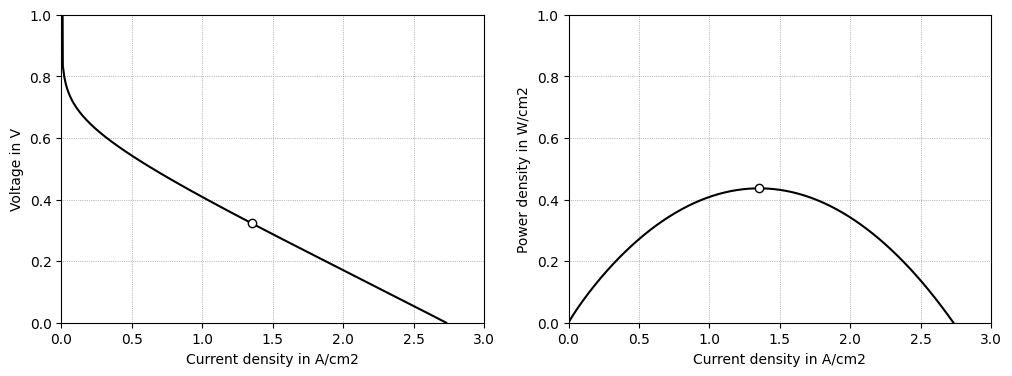

In [66]:
_ = plot_optimization_result_fuel_cell(instance.fuel_cell)

In [67]:
from phdtools.optimization.postprocessing import get_reference_values_fuel_cell

In [68]:
data_id = DataID(DataType.FIGURE, Chapter.RESULTS, 3)


@auto_create_path
def save_pem_fuel_cell_performance_verification(path, results_id):

    pathlist = list(results_id.get_path(fail_exists=False).glob("results*"))

    run_ids = np.zeros(len(pathlist), dtype=int)

    cellVoltageValues = np.full(len(pathlist), np.nan)
    currentDensityValues = np.full(len(pathlist), np.nan)
    powerDensityValues = np.full(len(pathlist), np.nan)
    electricalPowerValuesSI = np.full(len(pathlist), np.nan)
    fuelCellActiveAreaValues = np.full(len(pathlist), np.nan)

    for num, pth in enumerate(pathlist):
        if pth.is_file():
            run_id = pth.stem.split("_")[-1]
            with chdir(results_id.get_path(fail_exists=False)):
                dp = pyo.DataPortal(filename=f"cost_minimization_{run_id}.dat")

            instance = pyomo_load_solution(pth, model=model, modeldata=dp)

            run_ids[num] = run_id
            currentDensityValues[num] = pyo.value(instance.fuel_cell.currentDensitySI)
            cellVoltageValues[num] = pyo.value(instance.fuel_cell.cellPotentialSI)
            powerDensityValues[num] = pyo.value(instance.fuel_cell.powerDensitySI)
            electricalPowerValuesSI[num] = pyo.value(instance.electricalPowerSI)
            fuelCellActiveAreaValues[num] = pyo.value(
                instance.fuel_cell.totalActiveAreaSI
            )

    df = (
        pd.DataFrame(
            {
                "RUN_ID": run_ids,
                "Fuel cell voltage (V)": cellVoltageValues,
                "Current density (A/cm2)": currentDensityValues * 1e-4,
                "Power density (W/cm2)": powerDensityValues * 1e-4,
                "Fuel cell area (cm2)": fuelCellActiveAreaValues * 1e4,
                "Electrical power (kW)": electricalPowerValuesSI * 1e-3,
            },
        )
        .set_index("RUN_ID")
        .sort_index()
    )

    description = (
        "Optimal fuel cell operating points obtained from the cost-minimization optimization problem.\n"
        "Reported values include current density, cell voltage, power density, active cell area, \n"
        "and electrical power output.\n"
        f"Note, the inlet conditions according to the optimization results are:\n"
        f"  p[H2,0] = {pyo.value(instance.shift.pressureBar*instance.shift.molarFlowRateSI["H2(ref)",instance.shift.setTimeSteps.last()]/sum(instance.shift.molarFlowRateSI[:,instance.shift.setTimeSteps.last()]))} bar\n"
        f"  p[O2,0] = {pyo.value(instance.shift.pressureBar*instance.molarFlowRateInSI["O2(ref)"]/(instance.molarFlowRateInSI["N2(ref)"]+instance.molarFlowRateInSI["O2(ref)"]+instance.molarFlowRateInSI["H2O1(g)"]))} bar\n"
        f"  p[H2O,0]= {pyo.value(instance.shift.pressureBar*instance.molarFlowRateInSI["H2O1(g)"]/(instance.molarFlowRateInSI["N2(ref)"]+instance.molarFlowRateInSI["O2(ref)"]+instance.molarFlowRateInSI["H2O1(g)"]))} bar\n"
        f"For parameter values and solver configuration see: {results_id.to_sqid()}.\n"
    )

    fname = path / f"{TODAY}_fuel_cell_operation_cost_minimization.csv"
    with open(fname, "w") as f:
        write_metadata(f, description)
        df.to_csv(f, index_label="RUN_ID")

    ref_values = get_reference_values_fuel_cell(instance.fuel_cell)
    ref_values["currentDensityRangeSI"] *= 1e-4
    ref_values["powerDenstiyValues"] *= 1e-4
    ref_values = ref_values.rename(
        columns={
            "currentDensityRangeSI": "j(A/cm2)",
            "fuelCellVoltageValues": "U(V)",
            "powerDenstiyValues": "p(W/cm2)",
        }
    )

    # TODO
    description = (
        f"Reference values for the polarization and power density curves obtained"
        f"from the PEM fuel cell model developed in this work.\n"
        f"Parameters:\n"
        f"  T = {pyo.value(instance.fuel_cell.temperatureKelvin)} K\n"
        f"  E0 = {pyo.value(instance.fuel_cell.reversibleCellPotentialSI)} V\n"
        f"  aC = {pyo.value(instance.fuel_cell.transferCoefficientCathode)}\n"
        f"  j0 = {pyo.value(instance.fuel_cell.exchangeCurrentDensityCathodeSI)*1e-4} A/cm2\n"
        f"  jL = {pyo.value(instance.fuel_cell.limitingCurrentDensitySI)*1e-4} A/cm2\n"
        f"  Rs = {pyo.value(instance.fuel_cell.areaSpecificResistanceSI)*1e4} Ohm*cm2\n"
    )

    fname = path / f"{TODAY}_fuel_cell_characteristics.csv"
    with open(fname, "w") as f:
        write_metadata(f, description)
        ref_values.to_csv(f, index=False)


save_pem_fuel_cell_performance_verification(
    data_id,
    results_id=DataID(DataType.SUPPORT, Chapter.RESULTS, 1),
    doc=(
        r"Optimal fuel cell operating points obtained from the cost-minimization problem "
        r"with reference polarization and power density curves from the PEM fuel cell model developed in "
        r"this work."
    ),
    overwrite=overwrite,
)

/Users/marvinmeck/test/phd-tools/phdtools/rdm.py:142: UserWarning: Results path '/Users/marvinmeck/Documents/git/phd-results/eH6Slm' already exists. The data_id has been used before. This may be because the results already exist. Skipping!
  warnings.warn(


In [69]:
!ls {DataID(DataType.FIGURE, Chapter.RESULTS, 3).get_path(fail_exists=False)}

260419_fuel_cell_characteristics.csv
260419_fuel_cell_operation_cost_minimization.csv


In [70]:
from phdtools.optimization.preprocessing import (
    get_reactorCostValues,
    get_fuelCellCostValues,
)

In [71]:
data_id = DataID(DataType.FIGURE, Chapter.UNUSED, 23)


@auto_create_path
def save_cost_model_verification(path, results_id):

    df = get_reactorCostValues(
        fname_cost_coefs=(
            DataID(DataType.SUPPORT, Chapter.METHODS, 6).get_path(fail_exists=False)
            / f"{FILE_DATE_REGRESSION}_cost_coefficients.json"
        ),
    )

    fname = path / f"{TODAY}_cost_values_reactor.csv"
    with open(fname, "w") as f:
        write_metadata(f)
        df.to_csv(f, index=False)

    df = get_fuelCellCostValues()
    fname = path / f"{TODAY}_cost_values_fuel_cell.csv"
    with open(fname, "w") as f:
        write_metadata(f)
        df.to_csv(f, index=False)

    pathlist = list(results_id.get_path(fail_exists=False).glob("results*"))

    run_ids = np.zeros(len(pathlist), dtype=int)

    catalystMassReformerSI = np.full(len(pathlist), np.nan)
    catalystMassShiftSI = np.full(len(pathlist), np.nan)
    fuelCellAreaSI = np.full(len(pathlist), np.nan)

    costValuesReformer = np.full(len(pathlist), np.nan)
    costValuesShift = np.full(len(pathlist), np.nan)
    costValuesFuelCell = np.full(len(pathlist), np.nan)

    for num, pth in enumerate(pathlist):
        if pth.is_file():
            run_id = pth.stem.split("_")[-1]
            with chdir(results_id.get_path(fail_exists=False)):
                dp = pyo.DataPortal(filename=f"cost_minimization_{run_id}.dat")

            instance = pyomo_load_solution(pth, model=model, modeldata=dp)

            run_ids[num] = run_id

            catalystMassReformerSI[num] = pyo.value(instance.reformer.massCatalystSI)
            costValuesReformer[num] = pyo.value(
                instance.costCoef["R1", "a1"]
                + instance.costCoef["R1", "a2"]
                * instance.reformer.massCatalystSI ** instance.costCoef["R1", "k"]
            )

            catalystMassShiftSI[num] = pyo.value(instance.shift.massCatalystSI)
            costValuesShift[num] = pyo.value(
                instance.costCoef["R2", "a1"]
                + instance.costCoef["R2", "a2"]
                * instance.shift.massCatalystSI ** instance.costCoef["R2", "k"]
            )

            fuelCellAreaSI[num] = pyo.value(instance.fuel_cell.totalActiveAreaSI)
            costValuesFuelCell[num] = pyo.value(
                instance.costCoef["FC", "a1"] * instance.fuel_cell.totalActiveAreaSI
            )

    df = (
        pd.DataFrame(
            {
                "RUN_ID": run_ids,
                "Catalyst mass reformer (g)": 1e3 * catalystMassReformerSI,
                "Catalyst mass shift (g)": 1e3 * catalystMassShiftSI,
                "Fuel cell area (cm2)": 1e4 * fuelCellAreaSI,
                "Costs reformer (Euro)": costValuesReformer,
                "Costs shift reactor (Euro)": costValuesShift,
                "Costs fuel cell (Euro)": costValuesFuelCell,
            },
        )
        .set_index("RUN_ID")
        .sort_index()
    )

    fname = path / f"{TODAY}_cost_values_cost_minimization.csv"
    with open(fname, "w") as f:
        write_metadata(f)
        df.to_csv(f)


save_cost_model_verification(
    data_id,
    results_id=DataID(DataType.SUPPORT, Chapter.RESULTS, 1),
    doc=(
        r"Optimal values for the individual cost terms obtained from the cost-minimization problem "
        r"with reference values from the cost model(s) developed in this work. "
    ),
    overwrite=overwrite,
)

/Users/marvinmeck/test/phd-tools/phdtools/rdm.py:142: UserWarning: Results path '/Users/marvinmeck/Documents/git/phd-results/7OdkDq' already exists. The data_id has been used before. This may be because the results already exist. Skipping!
  warnings.warn(


In [72]:
!ls {DataID(DataType.FIGURE, Chapter.UNUSED, 23).get_path(fail_exists=False)}

260419_cost_values_cost_minimization.csv
260419_cost_values_fuel_cell.csv
260419_cost_values_reactor.csv


In [73]:
# df = pd.read_csv(
#     (DataID(DataType.FIGURE, Chapter.UNUSED, 23).get_path(fail_exists=False)
#      / f"{FILE_DATE}_cost_values_reactor.csv"),
#     comment="#"
# )
df = pd.read_csv(
    (
        DataID(DataType.FIGURE, Chapter.UNUSED, 23).get_path(fail_exists=False)
        / f"{FILE_DATE}_cost_values_cost_minimization.csv"
    ),
    index_col=0,
    comment="#",
)

df

,Catalyst mass reformer (g),Catalyst mass shift (g),Fuel cell area (cm2),Costs reformer (Euro),Costs shift reactor (Euro),Costs fuel cell (Euro)
RUN_ID,,,,,,
1,0.710255,394.314988,687.603111,1858.468543,1943.520544,137.520622
2,0.713030,395.855299,802.203633,1858.471096,1943.766132,160.440727
3,0.715804,397.395609,916.804156,1858.473646,1944.011464,183.360831
4,0.718579,398.935919,1031.404674,1858.476193,1944.256541,206.280935
5,0.721353,400.476230,1146.005200,1858.478738,1944.501364,229.201040
6,0.724128,402.016540,1260.605723,1858.481281,1944.745935,252.121145
7,0.726902,403.556850,1375.206245,1858.483820,1944.990256,275.041249
8,0.729676,405.097161,1489.806763,1858.486357,1945.234326,297.961353
9,0.732451,406.637471,1604.407285,1858.488892,1945.478147,320.881457


#### Solution statistics
[back](#Table-of-contents)

In [74]:
from pyomo.opt import SolverResults, SolverStatus

In [75]:
# !ls {DataID(DataType.SUPPORT, Chapter.RESULTS, 1).get_path(fail_exists=False)}

In [76]:
data_id = DataID(DataType.TABLE, Chapter.RESULTS, 2)


@auto_create_path
def save_cost_minimization_solution_statistics(path, results_id):
    pathlist = list(results_id.get_path(fail_exists=False).glob("results*"))

    run_ids = np.zeros(len(pathlist), dtype=int)

    # epsThermalEfficiencyValues = np.full(len(pathlist), np.nan)
    epsElectricalPowerValuesSI = np.full(len(pathlist), np.nan)

    solverTimeValues = np.full(len(pathlist), np.nan)
    solverNodeCountValues = np.zeros(len(pathlist), dtype=int)
    solverPrimalBoundValues = np.full(len(pathlist), np.nan)
    solverDualBoundValues = np.full(len(pathlist), np.nan)
    solverGapValues = np.full(len(pathlist), np.nan)

    for num, pth in enumerate(pathlist):
        if pth.is_file():
            results = SolverResults()
            results.read(filename=pth)
            run_id = pth.stem.split("_")[-1]

            if (results.solver.status == SolverStatus.ok) and (
                results.solver.termination_condition
                != pyo.TerminationCondition.infeasible
            ):
                run_ids[num] = int(run_id)
                solverTimeValues[num] = results.solver.time
                solverNodeCountValues[num] = int(results.solver.node_count)
                solverPrimalBoundValues[num] = results.solver.primal_bound
                solverDualBoundValues[num] = results.solver.dual_bound
                solverGapValues[num] = results.solver.Gap

                with chdir(results_id.get_path(fail_exists=False)):
                    dp = pyo.DataPortal(filename=f"cost_minimization_{run_id}.dat")

                instance = pyomo_load_solution(pth, model=model, modeldata=dp)

                # epsThermalEfficiencyValues[num] = pyo.value(
                #     instance.epsThermalEfficiency
                # )
                epsElectricalPowerValuesSI[num] = pyo.value(
                    instance.epsElectricalPowerSI
                )

    df = (
        pd.DataFrame(
            {
                "RUN_ID": run_ids,
                # "Min. thermal Efficiency": epsThermalEfficiencyValues,
                "Min. el. Power (W)": epsElectricalPowerValuesSI,
                "Time (sec)": solverTimeValues,
                "Nodes": solverNodeCountValues,
                "Primal bound": solverPrimalBoundValues,
                "Dual bound": solverDualBoundValues,
                "Gap (percent)": solverGapValues,
            },
        )
        .set_index("RUN_ID")
        .sort_index()
    )

    df.drop_duplicates()

    frame = df.copy()  # .drop("epsThermalEfficiency",axis=1)
    frame["Primal bound"] = np.round(df["Primal bound"] * 1e4) / 1e4
    frame["Dual bound"] = np.round(df["Dual bound"] * 1e4) / 1e4

    frame = frame.drop_duplicates()

    description = (
        r"Solver statistics for the cost minimization problem (using \SCIP{}); \n"
        f"For parameter values and solver configurations see: {results_id.to_sqid()}"
    )

    fname = path / f"{TODAY}_cost_minimization_solver_statistics.csv"
    with open(fname, "w") as f:
        write_metadata(f)
        frame.T.to_csv(f, index_label="RUN_ID")


save_cost_minimization_solution_statistics(
    data_id,
    results_id=DataID(DataType.SUPPORT, Chapter.RESULTS, 1),
    doc=(
        rf"Solver statistics for the cost minimization problem (using \SCIP{{}}); "
        rf"For parameter values and solver configurations see: \texttt{{{DataID(DataType.SUPPORT, Chapter.RESULTS, 1).to_sqid()}}}"
    ),
    overwrite=overwrite,
)

/Users/marvinmeck/test/phd-tools/phdtools/rdm.py:142: UserWarning: Results path '/Users/marvinmeck/Documents/git/phd-results/PuNWM4' already exists. The data_id has been used before. This may be because the results already exist. Skipping!
  warnings.warn(


In [77]:
!ls {DataID(DataType.TABLE, Chapter.RESULTS, 2).get_path(fail_exists=False)}

260419_cost_minimization_solver_statistics.csv


In [78]:
df = pd.read_csv(
    DataID(DataType.TABLE, Chapter.RESULTS, 2).get_path(fail_exists=False)
    / f"{FILE_DATE}_cost_minimization_solver_statistics.csv",
    index_col=0,
    comment="#",
)
df

,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
RUN_ID,,,,,,,,,,,,,,,
Min. el. Power (W),300.0000,350.0000,400.0000,450.0000,500.0000,550.0000,600.0000,650.0000,700.0000,750.0000,800.0000,850.0000,900.0000,950.0000,1000.0000
Time (sec),3600.0000,3600.0000,3600.0000,3600.0000,3600.0000,3600.0000,3600.0000,3600.0000,3600.0000,3600.0000,3600.0000,3600.0000,3600.0000,3600.0000,3600.0000
Nodes,848.0000,1737.0000,808.0000,392.0000,1410.0000,607.0000,1250.0000,3181.0000,1235.0000,450.0000,1555.0000,577.0000,80.0000,532.0000,1039.0000
Primal bound,8939.5097,8962.6780,8985.8459,9009.0137,9032.1811,9055.3484,9078.5153,9101.6820,9124.8485,9148.0147,9171.1807,9194.3464,9217.5118,9240.6771,9263.8421
Dual bound,8858.7214,8881.6415,8904.5616,8927.4817,8950.4018,8973.3219,8996.2420,9019.1621,9042.0822,9065.0023,9087.9224,9110.8425,9133.7626,9156.6827,9179.6028
Gap (percent),0.9100,0.9100,0.9100,0.9100,0.9100,0.9100,0.9100,0.9100,0.9200,0.9200,0.9200,0.9200,0.9200,0.9200,0.9200


## Consumer preference analysis
[back](#Table-of-contents)

In [79]:
from phdtools.models.rommel_sagebiel_2017 import (
    compute_sample_avg_mxl_prob,
    compute_sample_avg_logit_prob,
)
from phdtools.optimization import (
    FEED_IN_TARIFF_EUR_PER_KWH,
    INVESTMENT_TYPE,
    CONTRACT_DURATION_YEARS,
)
from phdtools.optimization.postprocessing import (
    get_sampleAverageMixedLogitProbability,
    get_sampleAverageLogitProbability,
)
from phdtools.optimization.postprocessing import (
    energyCostSavingsModel,
    carbonDioxideEmissionReductionsModel,
)

In [80]:
model = create_abstract_model()

run_id = 1

fname = (
    DataID(DataType.SUPPORT, Chapter.RESULTS, 1).get_path(fail_exists=False)
    / f"results_{run_id}.yaml"
)
with chdir(DataID(DataType.SUPPORT, Chapter.RESULTS, 1).get_path(fail_exists=False)):
    dp = pyo.DataPortal(filename=f"cost_minimization_{run_id}.dat")

instance = pyomo_load_solution(fname, model=model, modeldata=dp)

WARNING (W1002): Setting Var 'electricalPowerScaled' to a numeric value
`0.299999989998377` outside the bounds (0.3, 1.0).
    See also https://pyomo.readthedocs.io/en/stable/errors.html#w1002
WARNING (W1002): Setting Var 'reformer.adsorptionCoefScaled['H2(ref)']' to a
numeric value `0.0156950765566375` outside the bounds (0.01569508619070076,
1.0).
    See also https://pyomo.readthedocs.io/en/stable/errors.html#w1002
WARNING (W1002): Setting Var 'shift.temperatureScaled' to a numeric value
`1.0000000044915325` outside the bounds (0.8661951639109242, 1.0).
    See also https://pyomo.readthedocs.io/en/stable/errors.html#w1002
WARNING (W1002): Setting Var 'shift.rateConstantScaled' to a numeric value
`1.0000000039063428` outside the bounds (0.8742855501588747, 1.0).
    See also https://pyomo.readthedocs.io/en/stable/errors.html#w1002
WARNING (W1002): Setting Var 'shift.equilibriumConstScaled' to a numeric value
`0.2429843129365326` outside the bounds (0.24298432293190536, 1.0).
    See 

In [81]:
# request_free_id(DataType.FIGURE, Chapter.UNUSED)

In [82]:
data_id = DataID(DataType.FIGURE, Chapter.UNUSED, 24)


@auto_create_path
def save_cost_minimization_pricing_strategies(
    path, results_id, markupRange, contributionRange
):
    model = create_abstract_model()

    pathlist = list(results_id.get_path(fail_exists=False).glob("results*"))

    run_ids = np.zeros(len(pathlist), dtype=int)
    thermalEfficiencyValues = np.full(len(pathlist), np.nan)
    electricalPowerValuesSI = np.full(len(pathlist), np.nan)
    variableCostsValues = np.full(len(pathlist), np.nan)

    for num, pth in enumerate(pathlist):
        if pth.is_file():
            run_id = pth.stem.split("_")[-1]
            with chdir(results_id.get_path(fail_exists=False)):
                dp = pyo.DataPortal(filename=f"cost_minimization_{run_id}.dat")

            instance = pyomo_load_solution(pth, model=model, modeldata=dp)

            run_ids[num] = int(run_id)
            thermalEfficiencyValues[num] = pyo.value(instance.thermalEfficiency)
            electricalPowerValuesSI[num] = pyo.value(instance.electricalPowerSI)
            variableCostsValues[num] = pyo.value(instance.variableCostsEuro)

    priceValuesMarkup = markupRange * variableCostsValues[:, np.newaxis]
    priceValuesContribution = contributionRange + variableCostsValues[:, np.newaxis]

    df = (
        pd.DataFrame(
            np.c_[
                run_ids,
                thermalEfficiencyValues,
                1e-3 * electricalPowerValuesSI,
                variableCostsValues,
                priceValuesMarkup,
            ],
            columns=[
                "RUN_ID",
                "Thermal efficiency",
                "Electrical power (kW)",
                "Variable costs (Euro)",
                *[f"Markup = {markup:.2f}" for markup in markupRange],
            ],
        )
        .set_index("RUN_ID")
        .sort_index()
    )

    description = (
        rf"Price vs. power based on constant markups applied to the optimal solutions \n"
        rf"of the cost minimisation problem, see: {results_id.to_sqid()}"
    )

    fname = path / f"{TODAY}_cost_minimization_price_w_constant_markup.csv"
    with open(fname, "w") as f:
        write_metadata(f, description)
        df.to_csv(f)

    df = (
        pd.DataFrame(
            np.c_[
                run_ids,
                thermalEfficiencyValues,
                1e-3 * electricalPowerValuesSI,
                variableCostsValues,
                priceValuesContribution,
            ],
            columns=[
                "RUN_ID",
                "Thermal efficiency",
                "Electrical power (kW)",
                "Variable costs (Euro)",
                *[
                    f"Contribution = {contribution:.2f} (Euro)"
                    for contribution in contributionRange
                ],
            ],
        )
        .set_index("RUN_ID")
        .sort_index()
    )

    description = (
        rf"Price vs. power based on constant contribution applied to the optimal solutions \n"
        rf"of the cost minimisation problem, see: {results_id.to_sqid()}"
    )

    fname = path / f"{TODAY}_cost_minimization_price_w_constant_contribution.csv"
    with open(fname, "w") as f:
        write_metadata(f, description)
        df.to_csv(f)


save_cost_minimization_pricing_strategies(
    data_id,
    results_id=DataID(DataType.SUPPORT, Chapter.RESULTS, 1),
    markupRange=np.array([1.5, 1.75, 2.0, 2.25, 2.5]),
    contributionRange=np.array([5000, 7000, 10000, 12000, 14000]),
    doc=(
        r"Values of price, electrical power, and efficiency calculated for "
        r"different pricing strategies applied to the optimal solutions of "
        r"the cost minimisation problem."
    ),
    overwrite=overwrite,
)

/Users/marvinmeck/test/phd-tools/phdtools/rdm.py:142: UserWarning: Results path '/Users/marvinmeck/Documents/git/phd-results/nWqPf7' already exists. The data_id has been used before. This may be because the results already exist. Skipping!
  warnings.warn(


In [83]:
!ls {DataID(DataType.FIGURE, Chapter.UNUSED, 24).get_path(fail_exists=False)}

260419_cost_minimization_price_w_constant_contribution.csv
260419_cost_minimization_price_w_constant_markup.csv


In [84]:
from phdtools.plots.optimization.postprocessing import plot_power_vs_cost_vs_price

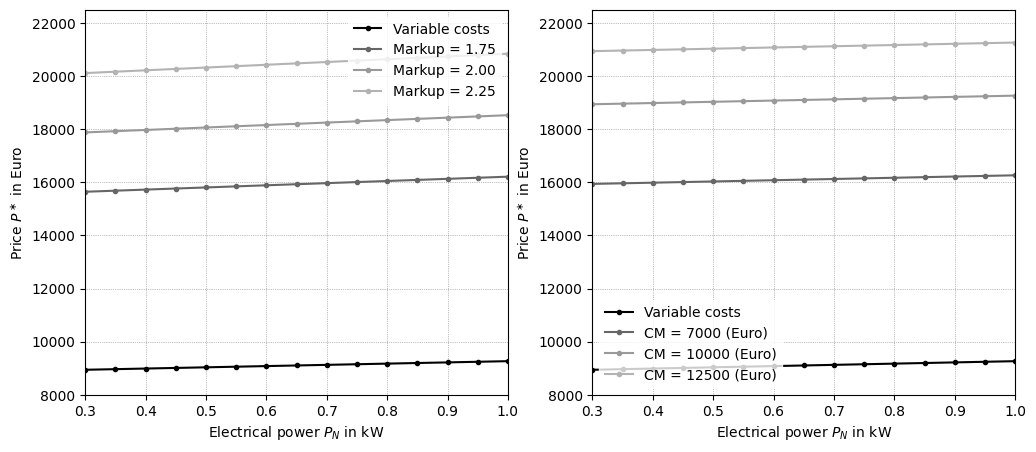

In [85]:
_ = plot_power_vs_cost_vs_price(
    fname_markup=(
        DataID(DataType.FIGURE, Chapter.UNUSED, 24).get_path(fail_exists=False)
        / f"{FILE_DATE}_cost_minimization_price_w_constant_markup.csv"
    ),
    fname_contribution=(
        DataID(DataType.FIGURE, Chapter.UNUSED, 24).get_path(fail_exists=False)
        / f"{FILE_DATE}_cost_minimization_price_w_constant_contribution.csv"
    ),
)

In [86]:
priceEuro = 2.0 * pyo.value(instance.variableCostsEuro)
thermalEfficiency = pyo.value(instance.thermalEfficiency)
powerIndex = pyo.value(instance.powerIndex)
matchingFactor = 0.5

In [87]:
get_sampleAverageMixedLogitProbability(
    priceEuro,
    thermalEfficiency,
    powerIndex,
    matchingFactor,
    data_id_socio_demographic_attributes=DataID(DataType.SUPPORT, Chapter.METHODS, 1),
    data_id_mxl_coefs=DataID(DataType.SUPPORT, Chapter.METHODS, 2),
    data_id_heating_demands=DataID(DataType.SUPPORT, Chapter.METHODS, 4),
    data_id_electricity_demands=DataID(DataType.SUPPORT, Chapter.METHODS, 5),
    file_date_demands=FILE_DATE_DEMANDS,
    file_date_agents=FILE_DATE_AGENTS,
    file_date_sample=FILE_DATE_SAMPLE,
    num_agents=NUM_AGENTS,
    mxl_coefs_sample_size=MXL_COEFS_SMAPLE_SIZE,
)

ALTERNATIVE
0    0.478493
Name: SAMPLE_AVG_MXL_PROB, dtype: float64

In [88]:
get_sampleAverageLogitProbability(
    priceEuro,
    thermalEfficiency,
    powerIndex,
    matchingFactor,
    data_id_socio_demographic_attributes=DataID(DataType.SUPPORT, Chapter.METHODS, 1),
    data_id_logit_coefs=DataID(DataType.SUPPORT, Chapter.METHODS, 3),
    data_id_heating_demands=DataID(DataType.SUPPORT, Chapter.METHODS, 4),
    data_id_electricity_demands=DataID(DataType.SUPPORT, Chapter.METHODS, 5),
    file_date_demands=FILE_DATE_DEMANDS,
    file_date_agents=FILE_DATE_AGENTS,
    file_date_logit_regression=FILE_DATE_REGRESSION,
    num_agents=16,
)

ALTERNATIVE
0    0.467819
Name: SAMPLE_AVG_LOGIT_PROB, dtype: float64

In [89]:
from phdtools.optimization.postprocessing import (
    calculate_consumer_preferences_cost_optimization_constant_markup,
)

df = calculate_consumer_preferences_cost_optimization_constant_markup(
    fname_results_summary=DataID(DataType.TABLE, Chapter.RESULTS, 1).get_path(
        fail_exists=False
    )
    / f"{FILE_DATE}_cost_minimization_solution_summary.csv",
    markup=2.0,
    fname_heat=(
        DataID(DataType.SUPPORT, Chapter.METHODS, 4).get_path(fail_exists=False)
        / f"{FILE_DATE_DEMANDS}_annual_heating_demands_{16}.csv"
    ),
    fname_electricity=(
        DataID(DataType.SUPPORT, Chapter.METHODS, 5).get_path(fail_exists=False)
        / f"{FILE_DATE_DEMANDS}_annual_electricity_demands_{16}.csv"
    ),
    data_id_socio_demographic_attributes=DataID(DataType.SUPPORT, Chapter.METHODS, 1),
    data_id_mxl_coefs=DataID(DataType.SUPPORT, Chapter.METHODS, 2),
    data_id_logit_coefs=DataID(DataType.SUPPORT, Chapter.METHODS, 3),
    data_id_heating_demands=DataID(DataType.SUPPORT, Chapter.METHODS, 4),
    data_id_electricity_demands=DataID(DataType.SUPPORT, Chapter.METHODS, 5),
    file_date_agents=FILE_DATE_AGENTS,
    file_date_sample=FILE_DATE_SAMPLE,
    file_date_demands=FILE_DATE_DEMANDS,
    file_date_logit_regression=FILE_DATE_REGRESSION,
    num_agents=NUM_AGENTS,
    mxl_coefs_sample_size=MXL_COEFS_SMAPLE_SIZE,
)
df

,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
RUN_ID,,,,,,,,,,,,,,,
"Normalized total contribution, MXL (Euro)",4277.496549,4292.129996,4306.765412,4321.314642,4335.793244,4350.249554,4364.648118,4379.017580,4393.336371,4407.474321,4421.475431,4435.397343,4449.202390,4462.903201,4476.536967
"Normalized total contribution, MNL (Euro)",4182.076052,4197.733773,4213.416181,4229.123219,4244.854833,4260.610967,4275.346837,4288.974731,4302.616773,4316.272956,4329.943272,4343.627714,4357.326276,4371.038948,4384.765728
"Market share, MXL (percent)",47.849342,47.888924,47.928325,47.966568,48.003834,48.040665,48.076673,48.112179,48.146951,48.179572,48.210537,48.240486,48.269017,48.296279,48.322682
"Market share, MNL (percent)",46.781940,46.835709,46.889477,46.943243,46.997007,47.050768,47.093018,47.122880,47.152748,47.182619,47.212496,47.242376,47.272261,47.302150,47.332043
Price (Euro),17879.019416,17925.355907,17971.691880,18018.027336,18064.362284,18110.696719,18157.030648,18203.364069,18249.696990,18296.029413,18342.361335,18388.692763,18435.023698,18481.354141,18527.684106
Variable costs (Euro),8939.509708,8962.677953,8985.845940,9009.013668,9032.181142,9055.348360,9078.515324,9101.682035,9124.848495,9148.014706,9171.180668,9194.346382,9217.511849,9240.677071,9263.842053
Contribution margin (Euro),8939.509708,8962.677953,8985.845940,9009.013668,9032.181142,9055.348360,9078.515324,9101.682035,9124.848495,9148.014706,9171.180668,9194.346382,9217.511849,9240.677071,9263.842053
Markup,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
Sample mean energy cost savings (percent),6.913393,7.104704,7.296014,7.487324,7.678634,7.869944,8.034815,8.171222,8.307628,8.444035,8.580441,8.716848,8.853254,8.989661,9.126067


In [90]:
from phdtools.optimization.postprocessing import (
    calculate_consumer_preferences_cost_optimization_constant_contribution,
)

df = calculate_consumer_preferences_cost_optimization_constant_contribution(
    fname_results_summary=DataID(DataType.TABLE, Chapter.RESULTS, 1).get_path(
        fail_exists=False
    )
    / f"{FILE_DATE}_cost_minimization_solution_summary.csv",
    fname_heat=(
        DataID(DataType.SUPPORT, Chapter.METHODS, 4).get_path(fail_exists=False)
        / f"{FILE_DATE_DEMANDS}_annual_heating_demands_{16}.csv"
    ),
    fname_electricity=(
        DataID(DataType.SUPPORT, Chapter.METHODS, 5).get_path(fail_exists=False)
        / f"{FILE_DATE_DEMANDS}_annual_electricity_demands_{16}.csv"
    ),
    data_id_socio_demographic_attributes=DataID(DataType.SUPPORT, Chapter.METHODS, 1),
    data_id_mxl_coefs=DataID(DataType.SUPPORT, Chapter.METHODS, 2),
    data_id_logit_coefs=DataID(DataType.SUPPORT, Chapter.METHODS, 3),
    data_id_heating_demands=DataID(DataType.SUPPORT, Chapter.METHODS, 4),
    data_id_electricity_demands=DataID(DataType.SUPPORT, Chapter.METHODS, 5),
    file_date_agents=FILE_DATE_AGENTS,
    file_date_sample=FILE_DATE_SAMPLE,
    file_date_demands=FILE_DATE_DEMANDS,
    file_date_logit_regression=FILE_DATE_REGRESSION,
    num_agents=NUM_AGENTS,
    mxl_coefs_sample_size=MXL_COEFS_SMAPLE_SIZE,
    contribution=8000,
)
df

,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
RUN_ID,,,,,,,,,,,,,,,
"Normalized total contribution, MXL (Euro)",3897.620547,3902.464389,3907.291680,3912.022846,3916.672522,3921.284744,3925.827889,3930.328126,3934.766365,3939.026897,3943.150103,3947.187988,3951.107617,3954.921052,3958.661849
"Normalized total contribution, MNL (Euro)",3829.134079,3835.574887,3842.015241,3848.455056,3854.894246,3861.332727,3866.853120,3871.386063,3875.919471,3880.453321,3884.987587,3889.522244,3894.057268,3898.592634,3903.128318
"Market share, MXL (percent)",48.720257,48.780805,48.841146,48.900286,48.958407,49.016059,49.072849,49.129102,49.184580,49.237836,49.289376,49.339850,49.388845,49.436513,49.483273
"Market share, MNL (percent)",47.864176,47.944686,48.025191,48.105688,48.186178,48.266659,48.335664,48.392326,48.448993,48.505667,48.562345,48.619028,48.675716,48.732408,48.789104
Price (Euro),16939.509708,16962.677953,16985.845940,17009.013668,17032.181142,17055.348360,17078.515324,17101.682035,17124.848495,17148.014706,17171.180668,17194.346382,17217.511849,17240.677071,17263.842053
Variable costs (Euro),8939.509708,8962.677953,8985.845940,9009.013668,9032.181142,9055.348360,9078.515324,9101.682035,9124.848495,9148.014706,9171.180668,9194.346382,9217.511849,9240.677071,9263.842053
Contribution margin (Euro),8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
Markup,1.894904,1.892590,1.890289,1.888000,1.885722,1.883456,1.881201,1.878958,1.876727,1.874507,1.872298,1.870100,1.867913,1.865737,1.863573
Sample mean energy cost savings (percent),6.913393,7.104704,7.296014,7.487324,7.678634,7.869944,8.034815,8.171222,8.307628,8.444035,8.580441,8.716848,8.853254,8.989661,9.126067


In [91]:
data_id = DataID(DataType.SUPPORT, Chapter.RESULTS, 2)


@auto_create_path
def save_cost_minimization_market_shares_and_contribution(
    path,
    markupRange=np.arange(150, 260, 5) / 100,
    contributionRange=np.arange(4000, 15500, 500),
):

    for markup in markupRange:
        df = calculate_consumer_preferences_cost_optimization_constant_markup(
            fname_results_summary=DataID(DataType.TABLE, Chapter.RESULTS, 1).get_path(
                fail_exists=False
            )
            / f"{FILE_DATE}_cost_minimization_solution_summary.csv",
            fname_heat=(
                DataID(DataType.SUPPORT, Chapter.METHODS, 4).get_path(fail_exists=False)
                / f"{FILE_DATE_DEMANDS}_annual_heating_demands_{16}.csv"
            ),
            fname_electricity=(
                DataID(DataType.SUPPORT, Chapter.METHODS, 5).get_path(fail_exists=False)
                / f"{FILE_DATE_DEMANDS}_annual_electricity_demands_{16}.csv"
            ),
            data_id_socio_demographic_attributes=DataID(
                DataType.SUPPORT, Chapter.METHODS, 1
            ),
            data_id_mxl_coefs=DataID(DataType.SUPPORT, Chapter.METHODS, 2),
            data_id_logit_coefs=DataID(DataType.SUPPORT, Chapter.METHODS, 3),
            data_id_heating_demands=DataID(DataType.SUPPORT, Chapter.METHODS, 4),
            data_id_electricity_demands=DataID(DataType.SUPPORT, Chapter.METHODS, 5),
            file_date_agents=FILE_DATE_AGENTS,
            file_date_sample=FILE_DATE_SAMPLE,
            file_date_demands=FILE_DATE_DEMANDS,
            file_date_logit_regression=FILE_DATE_REGRESSION,
            num_agents=NUM_AGENTS,
            mxl_coefs_sample_size=MXL_COEFS_SMAPLE_SIZE,
            markup=markup,
        )

        description = (
            f"Expected market share and normalized total contribution calculated for the optimal solutions \n"
            f"of the cost minimization problem assuming a pricing strategy with constant markup: \n"
            f"  Markup = Price / Variable costs = {markup}\n"
            f"The values for the MXL model (Rommel and Sagebiel, 2017) are calculated using {NUM_AGENTS} agents \n"
            f"and {MXL_COEFS_SMAPLE_SIZE} realizations of the random coefficients. \n"
            f"The values for the MNL model are calculated according to the reduced approximation used in the choice-\n"
            f"based optimization models with 16 agents. Note, that the actual sample size is further reduced since\n"
            f"decision makers with HEASTSYS = 0 are removed from the sample prior to evaluating the choice probabilities.\n\n"
            f"References:\n"
            f"-----------\n"
            f"Rommel, K. and Sagebiel, J. (2017) 'Preferences for micro-cogeneration in\n"
            f"    Germany: Policy implications for grid expansion from a discrete choice\n"
            f"    experiment', Applied Energy, 206, pp. 612–622. Available at:\n"
            f"    https://doi.org/10.1016/j.apenergy.2017.08.216.\n"
        )

        fname = path / (
            f"{TODAY}_cost_minimization_constant_markup_"
            + f"{markup:.2f}".replace(".", "_")
            + ".csv"
        )
        with open(fname, "w") as f:
            write_metadata(f, description)
            df.to_csv(f)

    for contribution in contributionRange:
        df = calculate_consumer_preferences_cost_optimization_constant_contribution(
            fname_results_summary=DataID(DataType.TABLE, Chapter.RESULTS, 1).get_path(
                fail_exists=False
            )
            / f"{FILE_DATE}_cost_minimization_solution_summary.csv",
            fname_heat=(
                DataID(DataType.SUPPORT, Chapter.METHODS, 4).get_path(fail_exists=False)
                / f"{FILE_DATE_DEMANDS}_annual_heating_demands_{16}.csv"
            ),
            fname_electricity=(
                DataID(DataType.SUPPORT, Chapter.METHODS, 5).get_path(fail_exists=False)
                / f"{FILE_DATE_DEMANDS}_annual_electricity_demands_{16}.csv"
            ),
            data_id_socio_demographic_attributes=DataID(
                DataType.SUPPORT, Chapter.METHODS, 1
            ),
            data_id_mxl_coefs=DataID(DataType.SUPPORT, Chapter.METHODS, 2),
            data_id_logit_coefs=DataID(DataType.SUPPORT, Chapter.METHODS, 3),
            data_id_heating_demands=DataID(DataType.SUPPORT, Chapter.METHODS, 4),
            data_id_electricity_demands=DataID(DataType.SUPPORT, Chapter.METHODS, 5),
            file_date_agents=FILE_DATE_AGENTS,
            file_date_sample=FILE_DATE_SAMPLE,
            file_date_demands=FILE_DATE_DEMANDS,
            file_date_logit_regression=FILE_DATE_REGRESSION,
            num_agents=NUM_AGENTS,
            mxl_coefs_sample_size=MXL_COEFS_SMAPLE_SIZE,
            contribution=contribution,
        )

        description = (
            f"Expected market share and normalized total contribution calculated for the optimal solutions \n"
            f"of the cost minimization problem assuming a pricing strategy with constant contribution margin: \n"
            f"  CM = Price - Variable costs = {contribution} Euro\n"
            f"The values for the MXL model (Rommel and Sagebiel, 2017) are calculated using {NUM_AGENTS} agents \n"
            f"and {MXL_COEFS_SMAPLE_SIZE} realizations of the random coefficients. \n"
            f"The values for the MNL model are calculated according to the reduced approximation used in the choice-\n"
            f"based optimization models with 16 agents. Note, that the actual sample size is further reduced since\n"
            f"decision makers with HEASTSYS = 0 are removed from the sample prior to evaluating the choice probabilities.\n\n"
            f"References:\n"
            f"-----------\n"
            f"Rommel, K. and Sagebiel, J. (2017) 'Preferences for micro-cogeneration in\n"
            f"    Germany: Policy implications for grid expansion from a discrete choice\n"
            f"    experiment', Applied Energy, 206, pp. 612–622. Available at:\n"
            f"    https://doi.org/10.1016/j.apenergy.2017.08.216.\n"
        )
        fname = (
            path / f"{TODAY}_cost_minimization_constant_contribution_{contribution}.csv"
        )
        with open(fname, "w") as f:
            write_metadata(f, description)
            df.to_csv(f)


save_cost_minimization_market_shares_and_contribution(
    data_id=data_id,
    doc=(
        r"Expected market share and normalized total contribution calculated for the optimal solutions "
        r"of the cost minimization problem assuming different pricing strategies."
    ),
    overwrite=overwrite,
)

/Users/marvinmeck/test/phd-tools/phdtools/rdm.py:142: UserWarning: Results path '/Users/marvinmeck/Documents/git/phd-results/uY2lYL' already exists. The data_id has been used before. This may be because the results already exist. Skipping!
  warnings.warn(


In [92]:
!ls {DataID(DataType.SUPPORT, Chapter.RESULTS, 2).get_path(fail_exists=False)}

260419_cost_minimization_constant_contribution_10000.csv
260419_cost_minimization_constant_contribution_10500.csv
260419_cost_minimization_constant_contribution_11000.csv
260419_cost_minimization_constant_contribution_11500.csv
260419_cost_minimization_constant_contribution_12000.csv
260419_cost_minimization_constant_contribution_12500.csv
260419_cost_minimization_constant_contribution_13000.csv
260419_cost_minimization_constant_contribution_13500.csv
260419_cost_minimization_constant_contribution_14000.csv
260419_cost_minimization_constant_contribution_14500.csv
260419_cost_minimization_constant_contribution_15000.csv
260419_cost_minimization_constant_contribution_4000.csv
260419_cost_minimization_constant_contribution_4500.csv
260419_cost_minimization_constant_contribution_5000.csv
260419_cost_minimization_constant_contribution_5500.csv
260419_cost_minimization_constant_contribution_6000.csv
260419_cost_minimization_constant_contribution_6500.csv
260419_cost_minimization_constant_con

In [93]:
# request_free_id(DataType.FIGURE, Chapter.UNUSED)

In [94]:
@auto_create_path
def save_cost_minimization_price_vs_market_share(
    path, fnames_markup, fnames_contribution
):
    frames = []
    for fname in fnames_markup:
        df = pd.read_csv(
            fname,
            comment="#",
            index_col=0,
        )
        df.index.name = ""
        frames.append(
            df.loc[
                [
                    "Markup",
                    "Contribution margin (Euro)",
                    "Electrical power (kW)",
                    "Variable costs (Euro)",
                    "Price (Euro)",
                    "Market share, MNL (percent)",
                    "Market share, MXL (percent)",
                    "Normalized total contribution, MNL (Euro)",
                    "Normalized total contribution, MXL (Euro)",
                ]
            ].T
        )

    frame = pd.concat(frames)
    frame.loc[:, "Markup"] = np.round(1e4 * frame["Markup"]) * 1e-4
    frame.loc[:, "Electrical power (kW)"] = (
        np.round(1e4 * frame["Electrical power (kW)"]) * 1e-4
    )

    fname = path / f"{TODAY}_cost_minimization_price_market_share_markup.csv"
    with open(fname, "w") as f:
        write_metadata(f)
        frame.to_csv(f, index=False)

    frames = []
    for fname in fnames_contribution:
        df = pd.read_csv(
            fname,
            comment="#",
            index_col=0,
        )
        df.index.name = ""
        frames.append(
            df.loc[
                [
                    "Markup",
                    "Contribution margin (Euro)",
                    "Electrical power (kW)",
                    "Variable costs (Euro)",
                    "Price (Euro)",
                    "Market share, MNL (percent)",
                    "Market share, MXL (percent)",
                    "Normalized total contribution, MNL (Euro)",
                    "Normalized total contribution, MXL (Euro)",
                ]
            ].T
        )

    frame = pd.concat(frames)
    frame.loc[:, "Contribution margin (Euro)"] = (
        np.round(1e4 * frame["Contribution margin (Euro)"]) * 1e-4
    )
    frame.loc[:, "Electrical power (kW)"] = (
        np.round(1e4 * frame["Electrical power (kW)"]) * 1e-4
    )

    fname = path / f"{TODAY}_cost_minimization_price_market_share_contribution.csv"
    with open(fname, "w") as f:
        write_metadata(f)
        frame.to_csv(f, index=False)

In [95]:
data_id = DataID(DataType.FIGURE, Chapter.UNUSED, 25)

# markupRange = np.arange(1.8,2.5,0.2)
# contributionRange = np.array([7000, 10000, 12000, 14000])

markupRange = np.arange(150, 260, 5) / 100
contributionRange = np.arange(4000, 15500, 500)

save_cost_minimization_price_vs_market_share(
    data_id,
    fnames_markup=[
        DataID(DataType.SUPPORT, Chapter.RESULTS, 2).get_path(fail_exists=False)
        / (
            f"{FILE_DATE}_cost_minimization_constant_markup_"
            + f"{markup:.2f}".replace(".", "_")
            + ".csv"
        )
        for markup in markupRange
    ],
    fnames_contribution=[
        DataID(DataType.SUPPORT, Chapter.RESULTS, 2).get_path(fail_exists=False)
        / (
            f"{FILE_DATE}_cost_minimization_constant_contribution_"
            + f"{contribution}".replace(".", "_")
            + ".csv"
        )
        for contribution in contributionRange
    ],
    doc=(
        r"Values of expected market share and normalized total contribution for different "
        r"pricing strategies applied to the optimal solutions of the cost minimisation problem."
    ),
    overwrite=overwrite,
)

/Users/marvinmeck/test/phd-tools/phdtools/rdm.py:142: UserWarning: Results path '/Users/marvinmeck/Documents/git/phd-results/Td1onM' already exists. The data_id has been used before. This may be because the results already exist. Skipping!
  warnings.warn(


In [96]:
!ls {DataID(DataType.FIGURE, Chapter.UNUSED, 25).get_path(fail_exists=False)}

260419_cost_minimization_price_market_share_contribution.csv
260419_cost_minimization_price_market_share_markup.csv


In [97]:
import matplotlib.pyplot as plt

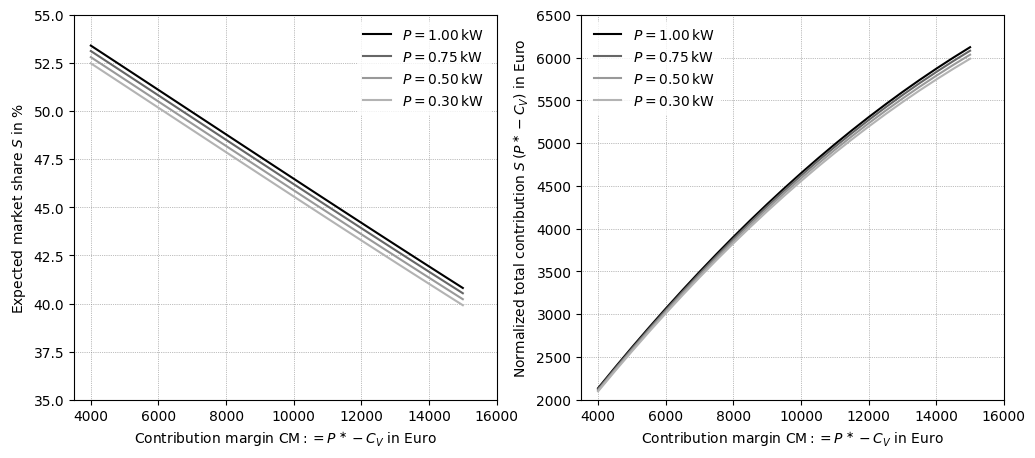

In [98]:
from phdtools.plots.optimization.postprocessing import (
    plot_cost_minimization_price_vs_market_share,
    plot_cost_minimization_price_vs_total_contribution,
)


def plot_cost_minimization_price_vs_market_share_vs_total_contribution(
    fname_contribution, powerValuesSI=None
):

    fig, axs = plt.subplots(1, 2, figsize=(12, 5))

    plot_cost_minimization_price_vs_market_share(
        fname_contribution, powerValuesSI, "mnl", axs[0]
    )
    plot_cost_minimization_price_vs_total_contribution(
        fname_contribution, powerValuesSI, "mnl", axs[1]
    )

    axs[0].set_xlabel(r"Contribution margin $\mathrm{{CM}} := P^\ast - C_V$ in Euro")
    axs[0].set_ylabel(r"Expected market share $S$ in %")

    axs[1].set_xlabel(r"Contribution margin $\mathrm{{CM}} := P^\ast - C_V$ in Euro")
    axs[1].set_ylabel(r"Normalized total contribution $S\,(P^\ast - C_V)$ in Euro")

    for ax in axs.flatten():
        ax.legend()
        ax.grid()

    for ax in axs.flatten():
        ax.set_xlim(3500, 16000)

    axs[0].set_ylim(35, 55)

    axs[1].set_ylim(2000, 6500)

    return fig


_ = plot_cost_minimization_price_vs_market_share_vs_total_contribution(
    fname_contribution=(
        DataID(DataType.FIGURE, Chapter.UNUSED, 25).get_path(fail_exists=False)
        / f"{FILE_DATE}_cost_minimization_price_market_share_contribution.csv"
    ),
    powerValuesSI=np.array([300, 500, 750, 1000]),
)

/var/folders/zx/th579dkn46lg9lcpb6980qb40000gn/T/ipykernel_52214/2709242636.py:70: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


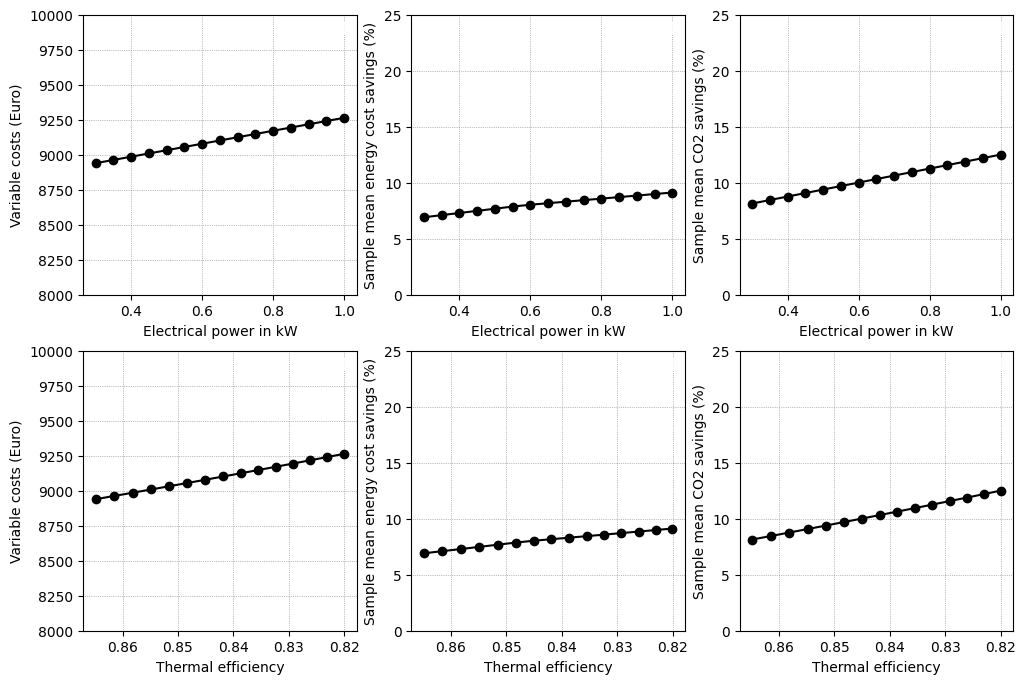

In [99]:
def plot_optimization_result_cost_and_carbon_savings(fname):

    # normalizedTotalContributionEuro = pyo.value(model.sampleAverageChoiceProbability) * pyo.value(model.priceEuro)

    fig, axs = plt.subplots(2, 3, figsize=(12, 8))
    ax = fig.gca()

    df = pd.read_csv(fname, comment="#", index_col=0)

    _ = axs[0, 0].plot(
        df.loc["Electrical power (kW)"], df.loc["Variable costs (Euro)"], marker="o"
    )
    _ = axs[0, 1].plot(
        df.loc["Electrical power (kW)"],
        df.loc["Sample mean energy cost savings (percent)"],
        marker="o",
    )
    _ = axs[0, 2].plot(
        df.loc["Electrical power (kW)"],
        df.loc["Sample mean CO2 savings (percent)"],
        marker="o",
    )

    _ = axs[1, 0].plot(
        df.loc["Thermal efficiency"], df.loc["Variable costs (Euro)"], marker="o"
    )
    _ = axs[1, 1].plot(
        df.loc["Thermal efficiency"],
        df.loc["Sample mean energy cost savings (percent)"],
        marker="o",
    )
    _ = axs[1, 2].plot(
        df.loc["Thermal efficiency"],
        df.loc["Sample mean CO2 savings (percent)"],
        marker="o",
    )

    axs[0, 0].set_xlabel("Electrical power in kW")
    axs[0, 0].set_ylabel("Variable costs (Euro)")

    axs[0, 1].set_xlabel("Electrical power in kW")
    axs[0, 1].set_ylabel("Sample mean energy cost savings (%)")

    axs[0, 2].set_xlabel("Electrical power in kW")
    axs[0, 2].set_ylabel("Sample mean CO2 savings (%)")

    axs[1, 0].set_xlabel("Thermal efficiency")
    axs[1, 0].set_ylabel("Variable costs (Euro)")

    axs[1, 1].set_xlabel("Thermal efficiency")
    axs[1, 1].set_ylabel("Sample mean energy cost savings (%)")

    axs[1, 2].set_xlabel("Thermal efficiency")
    axs[1, 2].set_ylabel("Sample mean CO2 savings (%)")

    axs[0, 0].set_ylim(8000, 10000)
    axs[0, 1].set_ylim(0, 25)
    axs[0, 2].set_ylim(0, 25)

    axs[1, 0].set_ylim(8000, 10000)
    axs[1, 1].set_ylim(0, 25)
    axs[1, 2].set_ylim(0, 25)

    axs[1, 0].xaxis.set_inverted(True)
    axs[1, 1].xaxis.set_inverted(True)
    axs[1, 2].xaxis.set_inverted(True)

    for ax in axs.flatten():
        ax.grid()
        ax.legend()

    return fig


_ = plot_optimization_result_cost_and_carbon_savings(
    fname=(
        DataID(DataType.SUPPORT, Chapter.RESULTS, 2).get_path(fail_exists=False)
        / f"{FILE_DATE}_cost_minimization_constant_markup_1_50.csv"
    )
)